# Packing for the notebook

In [1]:
# General
import numpy as np
import pandas as pd
import random

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Scaling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Save model
import os
import json
import joblib

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Ensure deterministic cuDNN behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Download data

In [2]:
# CSV file path
csv_url = "https://raw.githubusercontent.com/SamueleDaverio/2025_ML_EES/main/Project/df_Final_Proj.zip"

# Load the CSV file
df = pd.read_csv(csv_url, compression="zip", sep=";")

# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

# Ensure gauge_id is treated as a string
df["gauge_id"] = df["gauge_id"].astype(str)

# Sort rows by gauge_id and date, reset index
df = df.sort_values(["gauge_id", "date"]).reset_index(drop=True)

# Display first rows and column names
print(df.head())
print(df.columns)

        date gauge_id  discharge_vol  waterlevel  precipitation  \
0 1998-09-02     2009        212.567     375.293           4.56   
1 1998-09-03     2009        270.637     375.623          10.61   
2 1998-09-04     2009        272.311     375.636          23.68   
3 1998-09-05     2009        266.048     375.603           5.75   
4 1998-09-06     2009        207.136     375.252           0.01   

   temperature_min  temperature_mean  temperature_max  rel_sun_dur   swe  \
0             8.78             12.85            18.39        47.40  0.00   
1             7.00             10.24            14.62        35.81  0.00   
2             5.38              8.69            12.61        28.67  0.56   
3             3.04              5.80             9.76        12.27  1.91   
4             1.58              6.87            12.36        91.73  3.03   

     area  elev_mean  elev_min  elev_max  slope_mean  glac_area_ch_cont  \
0  5239.4    2124.19    377.07   4521.34       25.72         655.

# Select basins based on glacier loss and percentage of ice-covered area of the basin

In [3]:
# Compute glacier loss for each basin and sort by volume loss
loss_info = []

for gid, g in df.groupby("gauge_id"):
    g_sorted = g.sort_values("date")

    # First and last rows of the time series
    g_first = g_sorted.iloc[0]
    g_last  = g_sorted.iloc[-1]

    # Compute losses
    area_loss = g_first["glac_area_ch_cont"] - g_last["glac_area_ch_cont"]
    vol_loss  = g_first["glac_vol_ch_cont"]  - g_last["glac_vol_ch_cont"]
    mass_loss = g_first["glac_mass_ch_cont"] - g_last["glac_mass_ch_cont"]

    # Compute % glacier cover at the beginning of the timeseries
    perc_glacier = (g_first["glac_area_ch_cont"] / g_first["area"]) * 100

    loss_info.append([gid, area_loss, vol_loss, mass_loss, perc_glacier])

# Convert to DataFrame
loss_df = pd.DataFrame(
    loss_info,
    columns=["gauge_id", "area_loss", "vol_loss", "mass_loss", "perc_glacier_area"]
)

# Sort by vol_loss
loss_df_sorted = loss_df.sort_values("vol_loss", ascending=True)

print(loss_df_sorted.to_string(index=False))

gauge_id  area_loss  vol_loss    mass_loss  perc_glacier_area
    2044   0.007255  0.000417     0.356000           0.001690
    2112   0.007255  0.000417     0.356000           0.038650
    2181   0.007255  0.000417     0.356000           0.002650
    2468   0.007255  0.000417     0.356000           0.011013
    2084   0.041632  0.000612     0.523237           0.013655
    2170   0.005837  0.001260     1.069237           0.003504
    2263   0.036313  0.001518     1.289316           0.084214
    2426   0.292824  0.005017     4.267895           0.312086
    2327   0.281639  0.010981     9.330263           1.224568
    2420   0.237253  0.011119     9.447974           0.102978
    2430   0.434111  0.017878    15.201868           3.157846
    2355   0.464850  0.020318    17.271026           0.516358
    2364   0.558871  0.028189    23.962684           0.648125
    2418   0.909195  0.031389    26.685737           0.471264
    2203   0.973768  0.033906    28.822421           1.513426
    2086

# Temporal split of selected basins into training, validation and test sets

In [4]:
# Select specific catchments
selected_basins = [str(basin_id) for basin_id in [2161, 2299, 2269, 2117, 2351, 2219, 2033, 2086]]
print("Manually selected basins:", selected_basins)

# Filter dataset to chosen basins and sort by gauge and date
df_sel = df[df["gauge_id"].isin(selected_basins)].copy()
df_sel = df_sel.sort_values(["gauge_id", "date"]).reset_index(drop=True)

# Temporal split function for a single basin (train/val/test)
def split_basin_time(df_basin, train_frac=0.6, val_frac=0.2):
    n = len(df_basin)
    i1 = int(n * train_frac)
    i2 = int(n * (train_frac + val_frac))
    return df_basin.iloc[:i1], df_basin.iloc[i1:i2], df_basin.iloc[i2:]

# Apply temporal split for each basin separately
train_list, val_list, test_list = [], [], []

for gid, g in df_sel.groupby("gauge_id"):
    g = g.sort_values("date")
    t, v, te = split_basin_time(g)
    train_list.append(t)
    val_list.append(v)
    test_list.append(te)

# Merge all basins into final train/val/test datasets
df_train = pd.concat(train_list)
df_val   = pd.concat(val_list)
df_test  = pd.concat(test_list)

# Print dataset sizes and check basin distribution
print("Train  :", df_train.shape)
print("Val    :", df_val.shape)
print("Test   :", df_test.shape)

Manually selected basins: ['2161', '2299', '2269', '2117', '2351', '2219', '2033', '2086']
Train  : (39152, 18)
Val    : (13048, 18)
Test   : (13056, 18)


# Feature selection for Model inputs

In [5]:
# Target variable
target_col = "discharge_vol"

# Dynamic features
base_features = [
    "waterlevel",
    "precipitation",
    "temperature_min",
    "temperature_mean",
    "temperature_max",
    "rel_sun_dur",
    "swe",
]

# Glacier-related dynamic features
glacier_features = [
    "glac_area_ch_cont",
    "glac_vol_ch_cont",
    "glac_mass_ch_cont",
]

# Static features
static_features = [
    "area",
    "elev_mean",
    "elev_min",
    "elev_max",
    "slope_mean",
]

# Feature sets for Model A (without glacier features) and Model B (with glacier features)
features_A = base_features + static_features
features_B = base_features + glacier_features + static_features

# Scaling feature sets for Model A and Model B

In [6]:
# Create separate scalers for each feature set
scaler_A = StandardScaler()
scaler_B = StandardScaler()

# Fit scalers on training data only
scaler_A.fit(df_train[features_A])
scaler_B.fit(df_train[features_B])

# Transform train/val/test splits for both models
train_A = scaler_A.transform(df_train[features_A])
val_A   = scaler_A.transform(df_val[features_A])
test_A  = scaler_A.transform(df_test[features_A])

train_B = scaler_B.transform(df_train[features_B])
val_B   = scaler_B.transform(df_val[features_B])
test_B  = scaler_B.transform(df_test[features_B])

# Convert scaled arrays back to DataFrames
train_A_df = pd.DataFrame(train_A, index=df_train.index, columns=features_A)
val_A_df   = pd.DataFrame(val_A, index=df_val.index, columns=features_A)
test_A_df  = pd.DataFrame(test_A, index=df_test.index, columns=features_A)

train_B_df = pd.DataFrame(train_B, index=df_train.index, columns=features_B)
val_B_df   = pd.DataFrame(val_B, index=df_val.index, columns=features_B)
test_B_df  = pd.DataFrame(test_B, index=df_test.index, columns=features_B)

# Display shapes and first rows for both model inputs
print("Model A \n")
print("Shape:", train_A_df.shape)
print("\nFirst 5 rows:")
print(train_A_df.head())

print("\n\n Model B \n")
print("Shape:", train_B_df.shape)
print("\nFirst 5 rows:")
print(train_B_df.head())

Model A 

Shape: (39152, 12)

First 5 rows:
   waterlevel  precipitation  temperature_min  temperature_mean  \
0   -0.680655      -0.448868         1.704005          1.752535   
1   -0.680488       1.451914         1.551950          1.372525   
2   -0.680703       5.550378         1.402790          1.397673   
3   -0.678834       2.020799         0.865526          0.687949   
4   -0.680230      -0.432258         0.927797          0.943618   

   temperature_max  rel_sun_dur       swe      area  elev_mean  elev_min  \
0         1.794025    -0.027580 -0.996865  1.565841  -1.057291  -0.67592   
1         1.205875    -0.884660 -0.996865  1.565841  -1.057291  -0.67592   
2         1.463677    -0.000675 -0.996865  1.565841  -1.057291  -0.67592   
3         0.530928    -1.156038 -0.992887  1.565841  -1.057291  -0.67592   
4         1.007666     0.696785 -0.988789  1.565841  -1.057291  -0.67592   

   elev_max  slope_mean  
0 -0.385919   -0.433343  
1 -0.385919   -0.433343  
2 -0.385919   -0.4

# Sliding-Window sequences for models training

In [7]:
# Sliding Window size
sequence_length = 270

# Build input sequences (X) and aligned targets (y)
def make_sequences(df_scaled, df_original, features, target, seq_len):
    values = df_scaled[features].values                                    # scaled feature matrix
    X = np.lib.stride_tricks.sliding_window_view(values, seq_len, axis=0)  # sliding windows
    X = np.moveaxis(X, 1, 2)                                               # reshape to (samples, seq_len, features)
    y = df_original[target].values[seq_len - 1:]                           # target aligned with end of each window
    return X.astype(np.float32), y.astype(np.float32)

# Generate sequences for Model A
X_train_A, y_train_A = make_sequences(train_A_df, df_train, features_A, target_col, sequence_length)
X_val_A,   y_val_A   = make_sequences(val_A_df,   df_val,   features_A, target_col, sequence_length)
X_test_A,  y_test_A  = make_sequences(test_A_df,  df_test,  features_A, target_col, sequence_length)

# Generate sequences for Model B
X_train_B, y_train_B = make_sequences(train_B_df, df_train, features_B, target_col, sequence_length)
X_val_B,   y_val_B   = make_sequences(val_B_df,   df_val,   features_B, target_col, sequence_length)
X_test_B,  y_test_B  = make_sequences(test_B_df,  df_test,  features_B, target_col, sequence_length)

#  Move Data to GPU/CPU and Create PyTorch DataLoaders

In [8]:
# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Build DataLoader from numpy arrays
def build_loader(X, y, batch=64, shuffle=True):
    g = torch.Generator()
    g.manual_seed(42)                                       # deterministic batching

    X_t = torch.tensor(X).to(device)                        # convert and move X to device
    y_t = torch.tensor(y).to(device)                        # convert and move y to device
    ds = TensorDataset(X_t, y_t)                            # dataset object
    dl = DataLoader(ds, batch_size=batch, shuffle=shuffle)
    return dl, ds

# Loaders for Model A
train_loader_A, train_data_A = build_loader(X_train_A, y_train_A)
val_loader_A,   val_data_A   = build_loader(X_val_A,   y_val_A,   shuffle=False)
test_loader_A,  test_data_A  = build_loader(X_test_A,  y_test_A,  shuffle=False)

# Loaders for Model B
train_loader_B, train_data_B = build_loader(X_train_B, y_train_B)
val_loader_B,   val_data_B   = build_loader(X_val_B,   y_val_B,   shuffle=False)
test_loader_B,  test_data_B  = build_loader(X_test_B,  y_test_B,  shuffle=False)


Using: cuda


# LSTM Model Architecture

In [9]:
class MyLSTM(nn.Module):
    """Two-layer LSTM with dropout and dense output, similar to CAMELS."""

    def __init__(self, input_size, hidden_size=56, num_layers=1, dropout=0.5):
        super(MyLSTM, self).__init__()

        # Store model dimensions
        self.input_size = input_size
        self.hidden_size = hidden_size

        # LSTM encoder (processes sequential inputs)
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # Dropout for regularization and linear output layer
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, X):

        # Run the LSTM and obtain the last hidden state
        out, (h_n, c_n) = self.lstm(X)
        h_last = self.dropout(h_n[-1])

        # Apply linear layer and activation to produce prediction
        pred = torch.flatten(torch.relu(self.fc(h_last)))

        return pred

# # Nash–Sutcliffe Efficiency (NSE) function

In [10]:
# NSE function definition
def calc_nse(sim, obs, global_mean):

    numerator = torch.sum((sim - obs)**2)
    denominator = torch.sum((obs - global_mean)**2)
    return 1 - numerator / denominator

# Training Loop for LSTM Model

In [11]:
# Training loop
def train_lstm(model, train_loader, val_loader, lr=1e-3, epochs=100, patience=10):

    # Optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_func = nn.MSELoss()

    # Early stopping setup
    best_val = np.inf
    patience_counter = 0

    # Metric storage
    train_losses = []
    val_losses = []
    train_NSEs = []
    val_NSEs = []

    # Global mean of observations for NSE calculation
    global_obs_mean = torch.cat([y for _, y in train_loader]).mean()

    for ep in range(epochs):

        # Training phase
        model.train()
        train_loss = 0
        preds_all, obs_all = [], []

        for Xb, yb in train_loader:
            optimizer.zero_grad()

            pred = model(Xb)
            loss = loss_func(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds_all.append(pred.detach())
            obs_all.append(yb.detach())

        train_loss /= len(train_loader)
        preds_all = torch.cat(preds_all)
        obs_all = torch.cat(obs_all)
        train_NSE = calc_nse(preds_all, obs_all, global_obs_mean).item()

        # Validation phase
        model.eval()
        val_loss = 0
        preds_val, obs_val = [], []

        with torch.no_grad():
            for Xb, yb in val_loader:
                p = model(Xb)
                preds_val.append(p)
                obs_val.append(yb)
                val_loss += loss_func(p, yb).item()

        val_loss /= len(val_loader)
        preds_val = torch.cat(preds_val)
        obs_val = torch.cat(obs_val)
        val_NSE = calc_nse(preds_val, obs_val, global_obs_mean).item()

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_NSEs.append(train_NSE)
        val_NSEs.append(val_NSE)

        # Early stopping update
        if val_loss < best_val:
            best_val = val_loss
            best_weights = {k: v.cpu() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("\nEarly stopping triggered.")
                break

        # Progress print
        print(
            f"\rEpoch {ep+1}/{epochs} | "
            f"train_loss={train_loss:.3f} | train_NSE={train_NSE:.3f} | "
            f"val_loss={val_loss:.3f} | val_NSE={val_NSE:.3f}",
            end=""
        )

    print("\nTraining complete.")

    # Load best model version
    model.load_state_dict(best_weights)

    return model, train_losses, val_losses, train_NSEs, val_NSEs

# # Train LSTM Models A and B

In [12]:
# Create model instances with correct input sizes
model_A = MyLSTM(input_size=len(features_A)).to(device)
model_B = MyLSTM(input_size=len(features_B)).to(device)

# Train Model A
model_A, trA_loss, valA_loss, trA_nse, valA_nse = train_lstm(
    model_A, train_loader_A, val_loader_A, lr=0.001, epochs=100
)

# Train Model B
model_B, trB_loss, valB_loss, trB_nse, valB_nse = train_lstm(
    model_B, train_loader_B, val_loader_B, lr=0.001, epochs=100
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.5 and num_layers=1
  warnings.warn(


Epoch 68/100 | train_loss=16.952 | train_NSE=0.930 | val_loss=20.104 | val_NSE=0.913
Early stopping triggered.

Training complete.
Epoch 39/100 | train_loss=20.518 | train_NSE=0.916 | val_loss=20.042 | val_NSE=0.913
Early stopping triggered.

Training complete.


# Save the best model scalers, training metrics, predictions and configuration

In [13]:
def get_predictions(model, test_loader):
    """Return predictions and observations without plotting."""
    model.eval()
    preds, obs = [], []

    with torch.no_grad():
        for Xb, yb in test_loader:
            preds.append(model(Xb).cpu().numpy())
            obs.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    obs = np.concatenate(obs)
    return preds, obs


# Create results folder
os.makedirs("results", exist_ok=True)


# Save model weights
torch.save(model_A.state_dict(), "results/model_A_weights.pt")
torch.save(model_B.state_dict(), "results/model_B_weights.pt")
print("Model weights saved.")


# Save scalers
joblib.dump(scaler_A, "results/scaler_A.pkl")
joblib.dump(scaler_B, "results/scaler_B.pkl")
print("Scalers saved.")


# Save training metrics for both models
np.savez(
    "results/training_A_metrics.npz",
    train_loss=np.array(trA_loss),
    val_loss=np.array(valA_loss),
    train_nse=np.array(trA_nse),
    val_nse=np.array(valA_nse)
)

np.savez(
    "results/training_B_metrics.npz",
    train_loss=np.array(trB_loss),
    val_loss=np.array(valB_loss),
    train_nse=np.array(trB_nse),
    val_nse=np.array(valB_nse)
)

print("Training metrics saved.")


# Save test predictions
pred_A, obs_A = get_predictions(model_A, test_loader_A)
pred_B, obs_B = get_predictions(model_B, test_loader_B)

np.savez("results/predictions_A.npz", pred=pred_A, obs=obs_A)
np.savez("results/predictions_B.npz", pred=pred_B, obs=obs_B)

print("Predictions saved.")


# Define config parameters for reproducibility
batch_size = 64
num_epochs = 100

config = {
    "sequence_length": sequence_length,
    "features_A": features_A,
    "features_B": features_B,
    "hidden_size": 56,
    "batch_size": batch_size,
    "learning_rate": 0.001,
    "epochs": num_epochs,
    "selected_basins": selected_basins
}

# Save configuration file
with open("results/config.json", "w") as f:
    json.dump(config, f, indent=4)

print("\nAll results saved successfully!")

Model weights saved.
Scalers saved.
Training metrics saved.
Predictions saved.

All results saved successfully!


# Compute metrics for Model A and Model B

In [14]:
# Metric functions
def mse(y_true, y_pred):
    """Mean Squared Error."""
    return np.mean((y_true - y_pred)**2)

def nse(y_true, y_pred):
    """Nash–Sutcliffe Efficiency."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return 1 - np.sum((y_pred - y_true)**2) / np.sum((y_true - np.mean(y_true))**2)

# Compute MSE and NSE from
def compute_metrics(df):
    obs = df["obs_sim"].values
    pred = df["pred"].values
    return mse(obs, pred), nse(obs, pred)

# Sequential prediction over the full dataframe using sliding windows
def predict_sequential(model, df_scaled, df_original, features, seq_len, device):
    """
    Perform autoregressive-style predictions using sliding windows.
    Returns a dataframe with aligned predictions and observations.
    """

    model.eval()

    # Extract input features and target values
    X = df_scaled[features].values.astype(np.float32)
    y = df_original[target_col].values.astype(np.float32)

    preds, obs = [], []

    with torch.no_grad():
        # Slide window from seq_len-1 to the end of the dataset
        for i in range(seq_len - 1, len(X)):
            window = X[i - (seq_len - 1): i + 1]
            window_t = torch.tensor(window).unsqueeze(0).to(device)
            pred = model(window_t).cpu().numpy()[0]

            preds.append(pred)
            obs.append(y[i])

    # Build output dataframe aligned with predictions
    df_out = df_original.iloc[seq_len - 1:].copy()
    df_out["pred"] = np.array(preds)
    df_out["obs_sim"] = np.array(obs)

    return df_out

# Sequential predictions for Model A on each split
df_train_A_full = predict_sequential(
    model_A, train_A_df, df_train, features_A, sequence_length, device
)
df_val_A_full = predict_sequential(
    model_A, val_A_df, df_val, features_A, sequence_length, device
)
df_test_A_full = predict_sequential(
    model_A, test_A_df, df_test, features_A, sequence_length, device
)

# Compute metrics for Model A
mse_train_A, nse_train_A = compute_metrics(df_train_A_full)
mse_val_A,   nse_val_A   = compute_metrics(df_val_A_full)
mse_test_A,  nse_test_A  = compute_metrics(df_test_A_full)

# Sequential predictions on the training set for Model B
df_train_full = predict_sequential(
    model_B, train_B_df, df_train, features_B, sequence_length, device
)

# Sequential predictions on the validation set for Model B
df_val_full = predict_sequential(
    model_B, val_B_df, df_val, features_B, sequence_length, device
)

# Sequential predictions on the test set for Model B
df_test_full = predict_sequential(
    model_B, test_B_df, df_test, features_B, sequence_length, device
)

# Compute metrics for Model B
mse_train_B, nse_train_B = compute_metrics(df_train_full)
mse_val_B,   nse_val_B   = compute_metrics(df_val_full)
mse_test_B,  nse_test_B  = compute_metrics(df_test_full)

# Print summary of metrics
print("\n MODEL A METRICS")
print(f"Train → MSE: {mse_train_A:.3f}, NSE: {nse_train_A:.3f}")
print(f"Val   → MSE: {mse_val_A:.3f}, NSE: {nse_val_A:.3f}")
print(f"Test  → MSE: {mse_test_A:.3f}, NSE: {nse_test_A:.3f}")

print("\n MODEL B METRICS")
print(f"Train → MSE: {mse_train_B:.3f}, NSE: {nse_train_B:.3f}")
print(f"Val   → MSE: {mse_val_B:.3f}, NSE: {nse_val_B:.3f}")
print(f"Test  → MSE: {mse_test_B:.3f}, NSE: {nse_test_B:.3f}")


 MODEL A METRICS
Train → MSE: 12.689, NSE: 0.948
Val   → MSE: 17.974, NSE: 0.922
Test  → MSE: 24.738, NSE: 0.907

 MODEL B METRICS
Train → MSE: 16.083, NSE: 0.934
Val   → MSE: 18.956, NSE: 0.917
Test  → MSE: 26.846, NSE: 0.899


# Final performance plot (Loss and NSE)

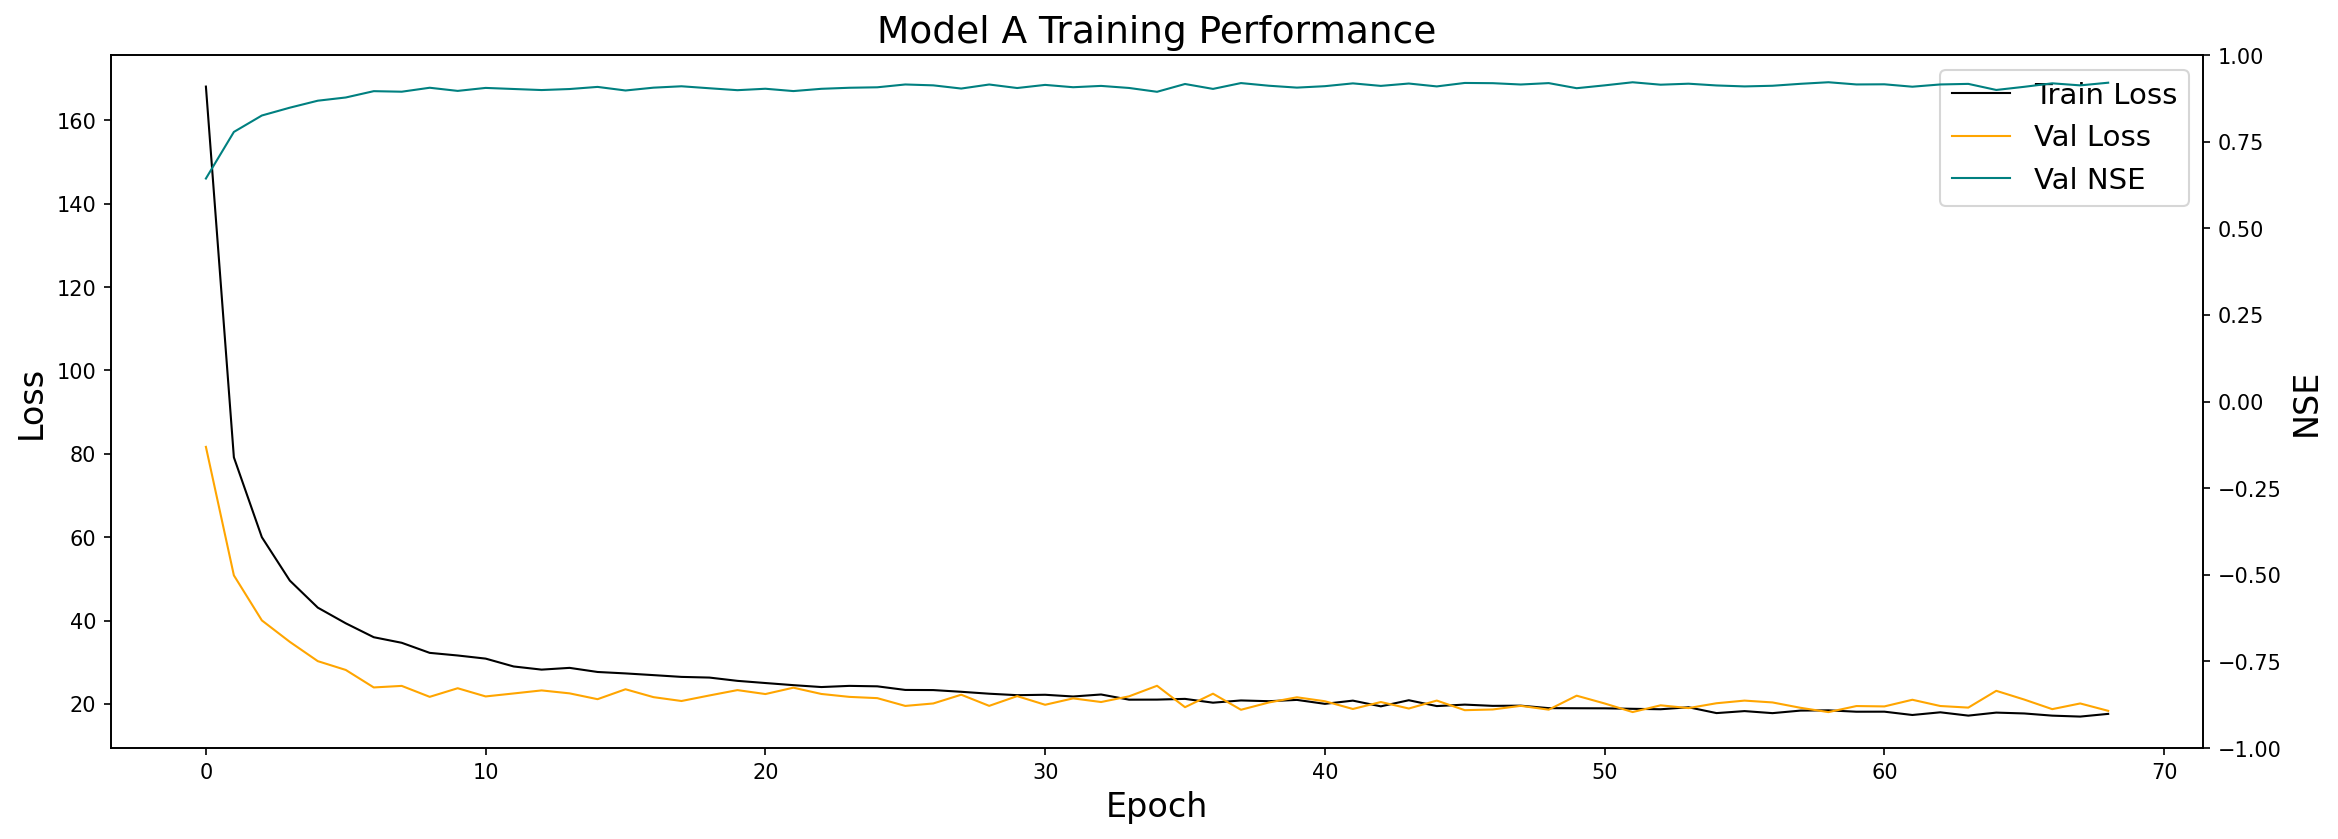

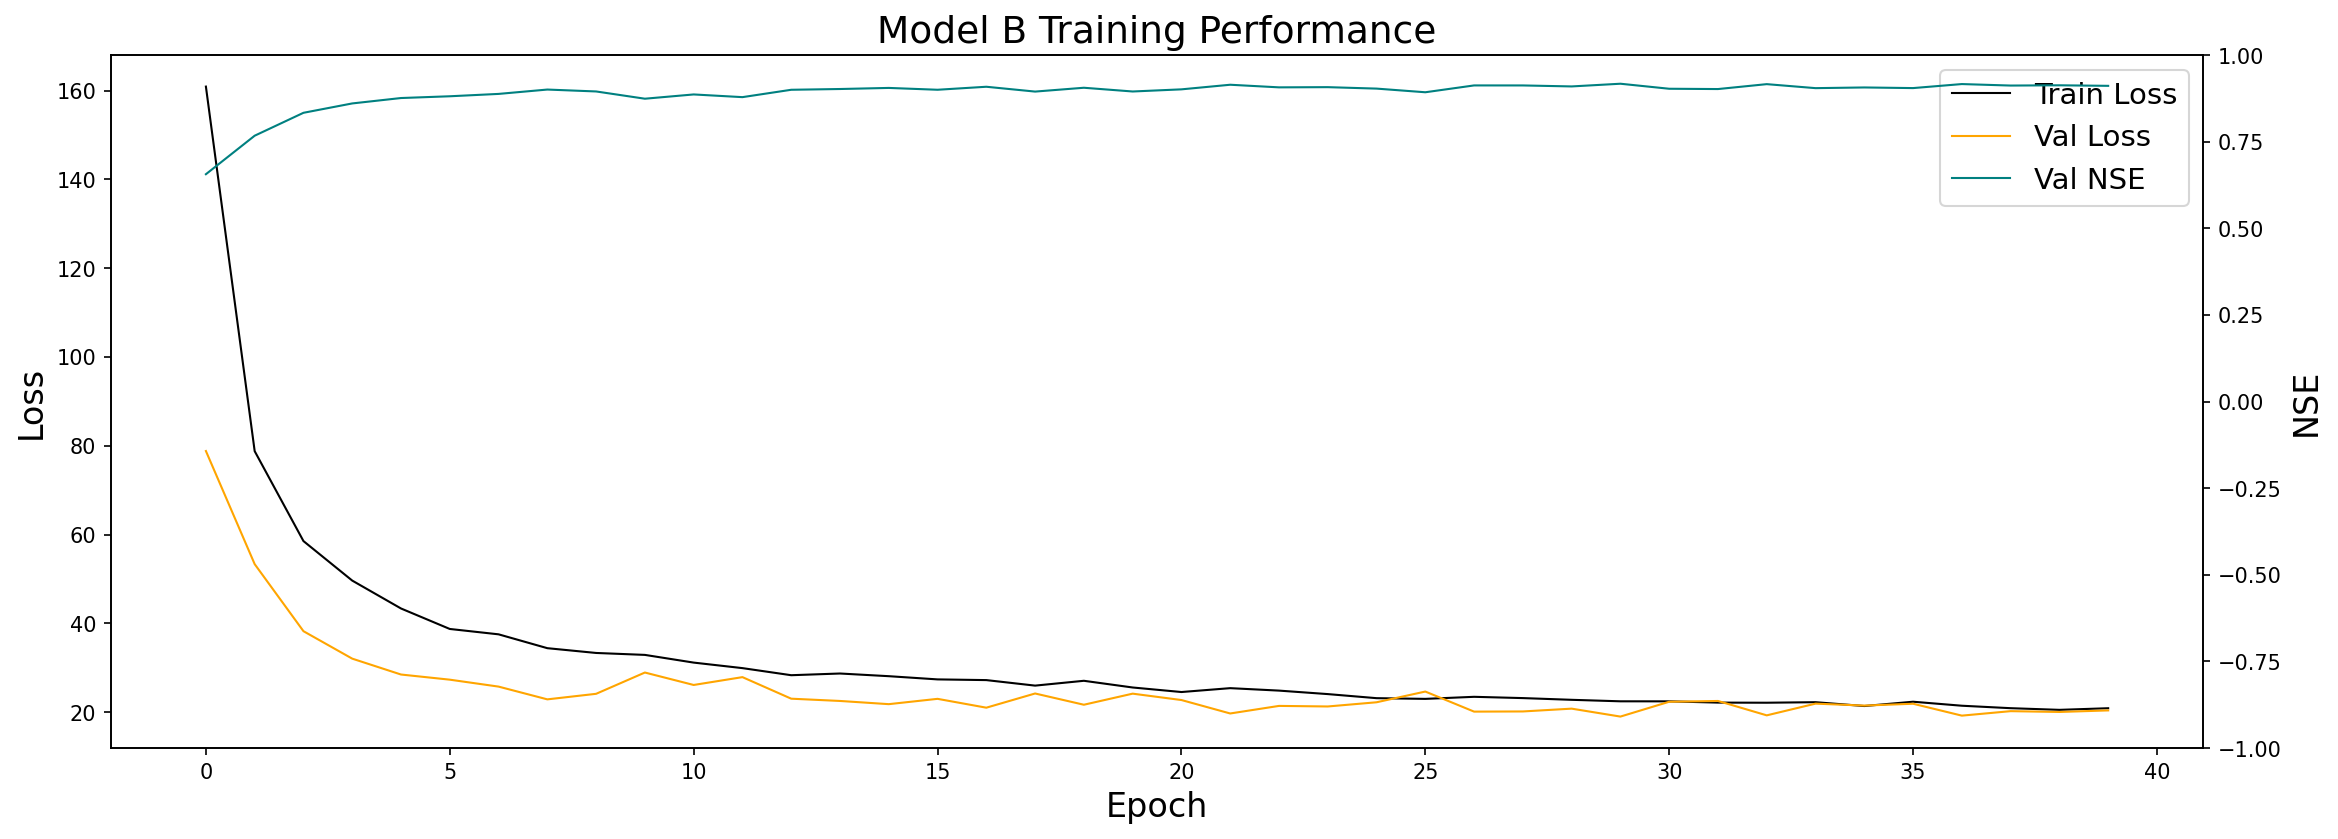

In [15]:
# Plot Training Curves for Loss and NSE
def plot_training(tr_loss, val_loss, val_NSE, title):
    fig, ax = plt.subplots(figsize=(18,6), dpi=150)

    # Plot training and validation loss
    ax.plot(tr_loss, label="Train Loss", color="black", linewidth=1)
    ax.plot(val_loss, label="Val Loss", color="orange", linewidth=1)
    ax.set_xlabel("Epoch", fontsize=16)
    ax.set_ylabel("Loss", fontsize=16)

    # Plot validation NSE on secondary axis
    ax2 = ax.twinx()
    ax2.plot(val_NSE, label="Val NSE", color="teal", linewidth=1)
    ax2.set_ylabel("NSE", fontsize=16)
    ax2.set_ylim([-1, 1])

    # Merge legends of both axes
    lines = ax.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc="upper right", fontsize=14)

    plt.title(title, fontsize=18)
    plt.show()

# Generate plots for both models
plot_training(trA_loss, valA_loss, valA_nse, "Model A Training Performance")
plot_training(trB_loss, valB_loss, valB_nse, "Model B Training Performance")

# Observed vs predicted streamflow plot

In [16]:
# Evaluate Model A on Test Set and Plot Observed vs Predicted Discharge
def evaluate_and_plot_model_A(model, test_loader, df_test, seq_len, basin_ids=None, layout="vertical"):

    model.eval()
    preds, obs = [], []

    # Collect predictions and observations
    with torch.no_grad():
        for Xb, yb in test_loader:
            preds.append(model(Xb).cpu().numpy())
            obs.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    obs = np.concatenate(obs)

    # Align predictions with test dataframe
    df_plot = df_test.copy().reset_index(drop=True)
    df_plot = df_plot.iloc[seq_len-1:].copy()
    df_plot["pred"] = preds
    df_plot["obs"] = obs
    df_plot["diff"] = df_plot["obs"] - df_plot["pred"]   # difference curve

    # Select basins to plot
    if basin_ids is None:
        basin_ids = df_plot["gauge_id"].unique()
    basin_ids = [b for b in basin_ids if b in df_plot["gauge_id"].unique()]
    n = len(basin_ids)

    # Figure layout
    if layout == "horizontal":
        fig, axes = plt.subplots(1, n, figsize=(6*n, 4), dpi=150, sharey=False)
    else:
        fig, axes = plt.subplots(n, 1, figsize=(20, 3*n), dpi=150)

    if n == 1:
        axes = [axes]

    # Plot for each selected basin
    for ax, basin in zip(axes, basin_ids):
        sub = df_plot[df_plot["gauge_id"] == basin]

        ax.plot(sub["date"], sub["obs"], label="Observed", color="black", linewidth=1.2)
        ax.plot(sub["date"], sub["pred"], label="Pred A", color="blue", alpha=0.8)
        ax.plot(sub["date"], sub["diff"], label="Obs - Pred A", color="green", linestyle="--")

        ax.set_title(f"Basin {basin} — Model A", fontsize=14)
        ax.set_ylabel("Discharge")
        ax.legend()

    plt.tight_layout()

    # Save plt in svg format
    plt.savefig("model_A_test.svg", format="svg", bbox_inches="tight")

    plt.show()

    return preds, obs, df_plot["diff"].values

In [17]:
# Evaluate Model B on Test Set and Plot Observed vs Predicted Discharge
def evaluate_and_plot_model_B(model, test_loader, df_test, seq_len, basin_ids=None, layout="vertical"):

    model.eval()
    preds, obs = [], []

    # Collect predictions and observations
    with torch.no_grad():
        for Xb, yb in test_loader:
            preds.append(model(Xb).cpu().numpy())
            obs.append(yb.cpu().numpy())

    preds = np.concatenate(preds)
    obs = np.concatenate(obs)

    # Align predictions with dataframe rows
    df_plot = df_test.copy().reset_index(drop=True)
    df_plot = df_plot.iloc[seq_len-1:].copy()
    df_plot["pred"] = preds
    df_plot["obs"] = obs
    df_plot["diff"] = df_plot["obs"] - df_plot["pred"]

    # Select basins
    if basin_ids is None:
        basin_ids = df_plot["gauge_id"].unique()
    basin_ids = [b for b in basin_ids if b in df_plot["gauge_id"].unique()]
    n = len(basin_ids)

    # Figure layout
    if layout == "horizontal":
        fig, axes = plt.subplots(1, n, figsize=(6*n, 4), dpi=150, sharey=False)
    else:
        fig, axes = plt.subplots(n, 1, figsize=(20, 3*n), dpi=150)

    if n == 1:
        axes = [axes]

    # Plot for each selected basin
    for ax, basin in zip(axes, basin_ids):
        sub = df_plot[df_plot["gauge_id"] == basin]

        ax.plot(sub["date"], sub["obs"], label="Observed", color="black", linewidth=1.2)
        ax.plot(sub["date"], sub["pred"], label="Pred B", color="red", alpha=0.8)
        ax.plot(sub["date"], sub["diff"], label="Obs - Pred B", color="green", linestyle="--")

        ax.set_title(f"Basin {basin} — Model B", fontsize=14)
        ax.set_ylabel("Discharge")
        ax.legend()

    plt.tight_layout()

    # Save plt in svg format
    plt.savefig("model_B_test.svg", format="svg", bbox_inches="tight")

    plt.show()

    return preds, obs, df_plot["diff"].values

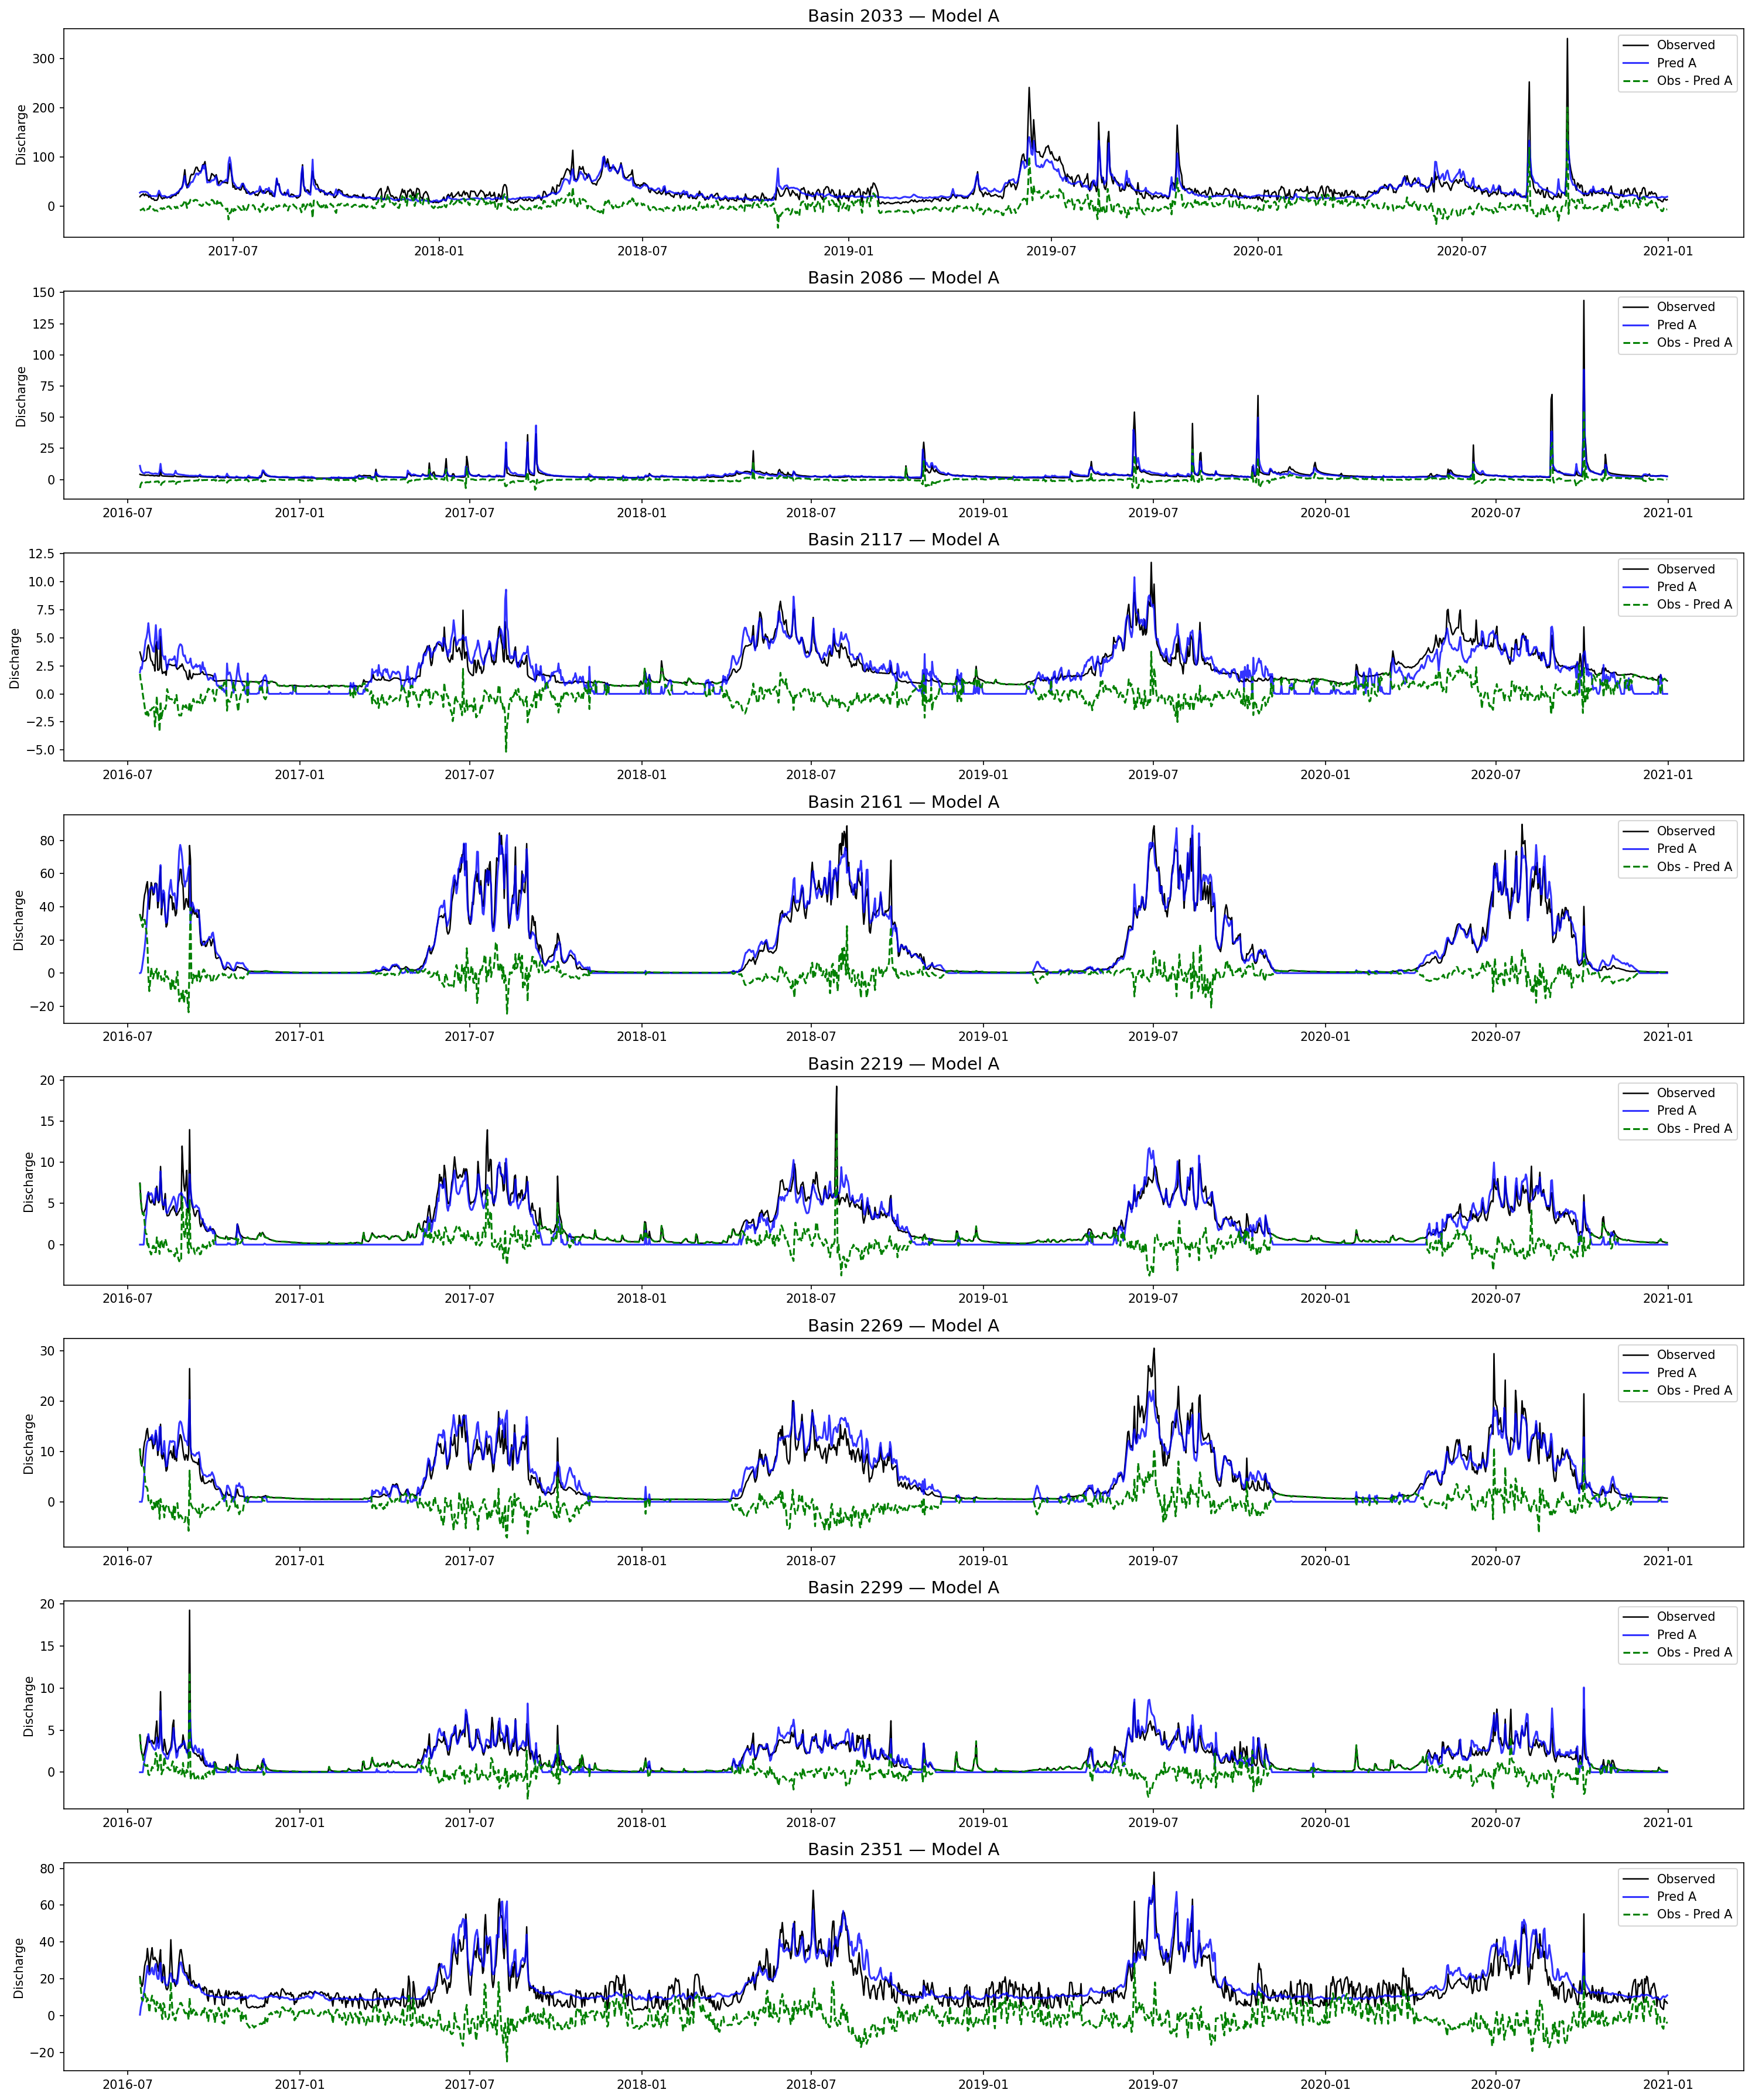

In [18]:
pred_A, obs_A, diff_A = evaluate_and_plot_model_A(
    model_A,
    test_loader_A,
    df_test,
    sequence_length,
    basin_ids=df_test["gauge_id"].unique()
)

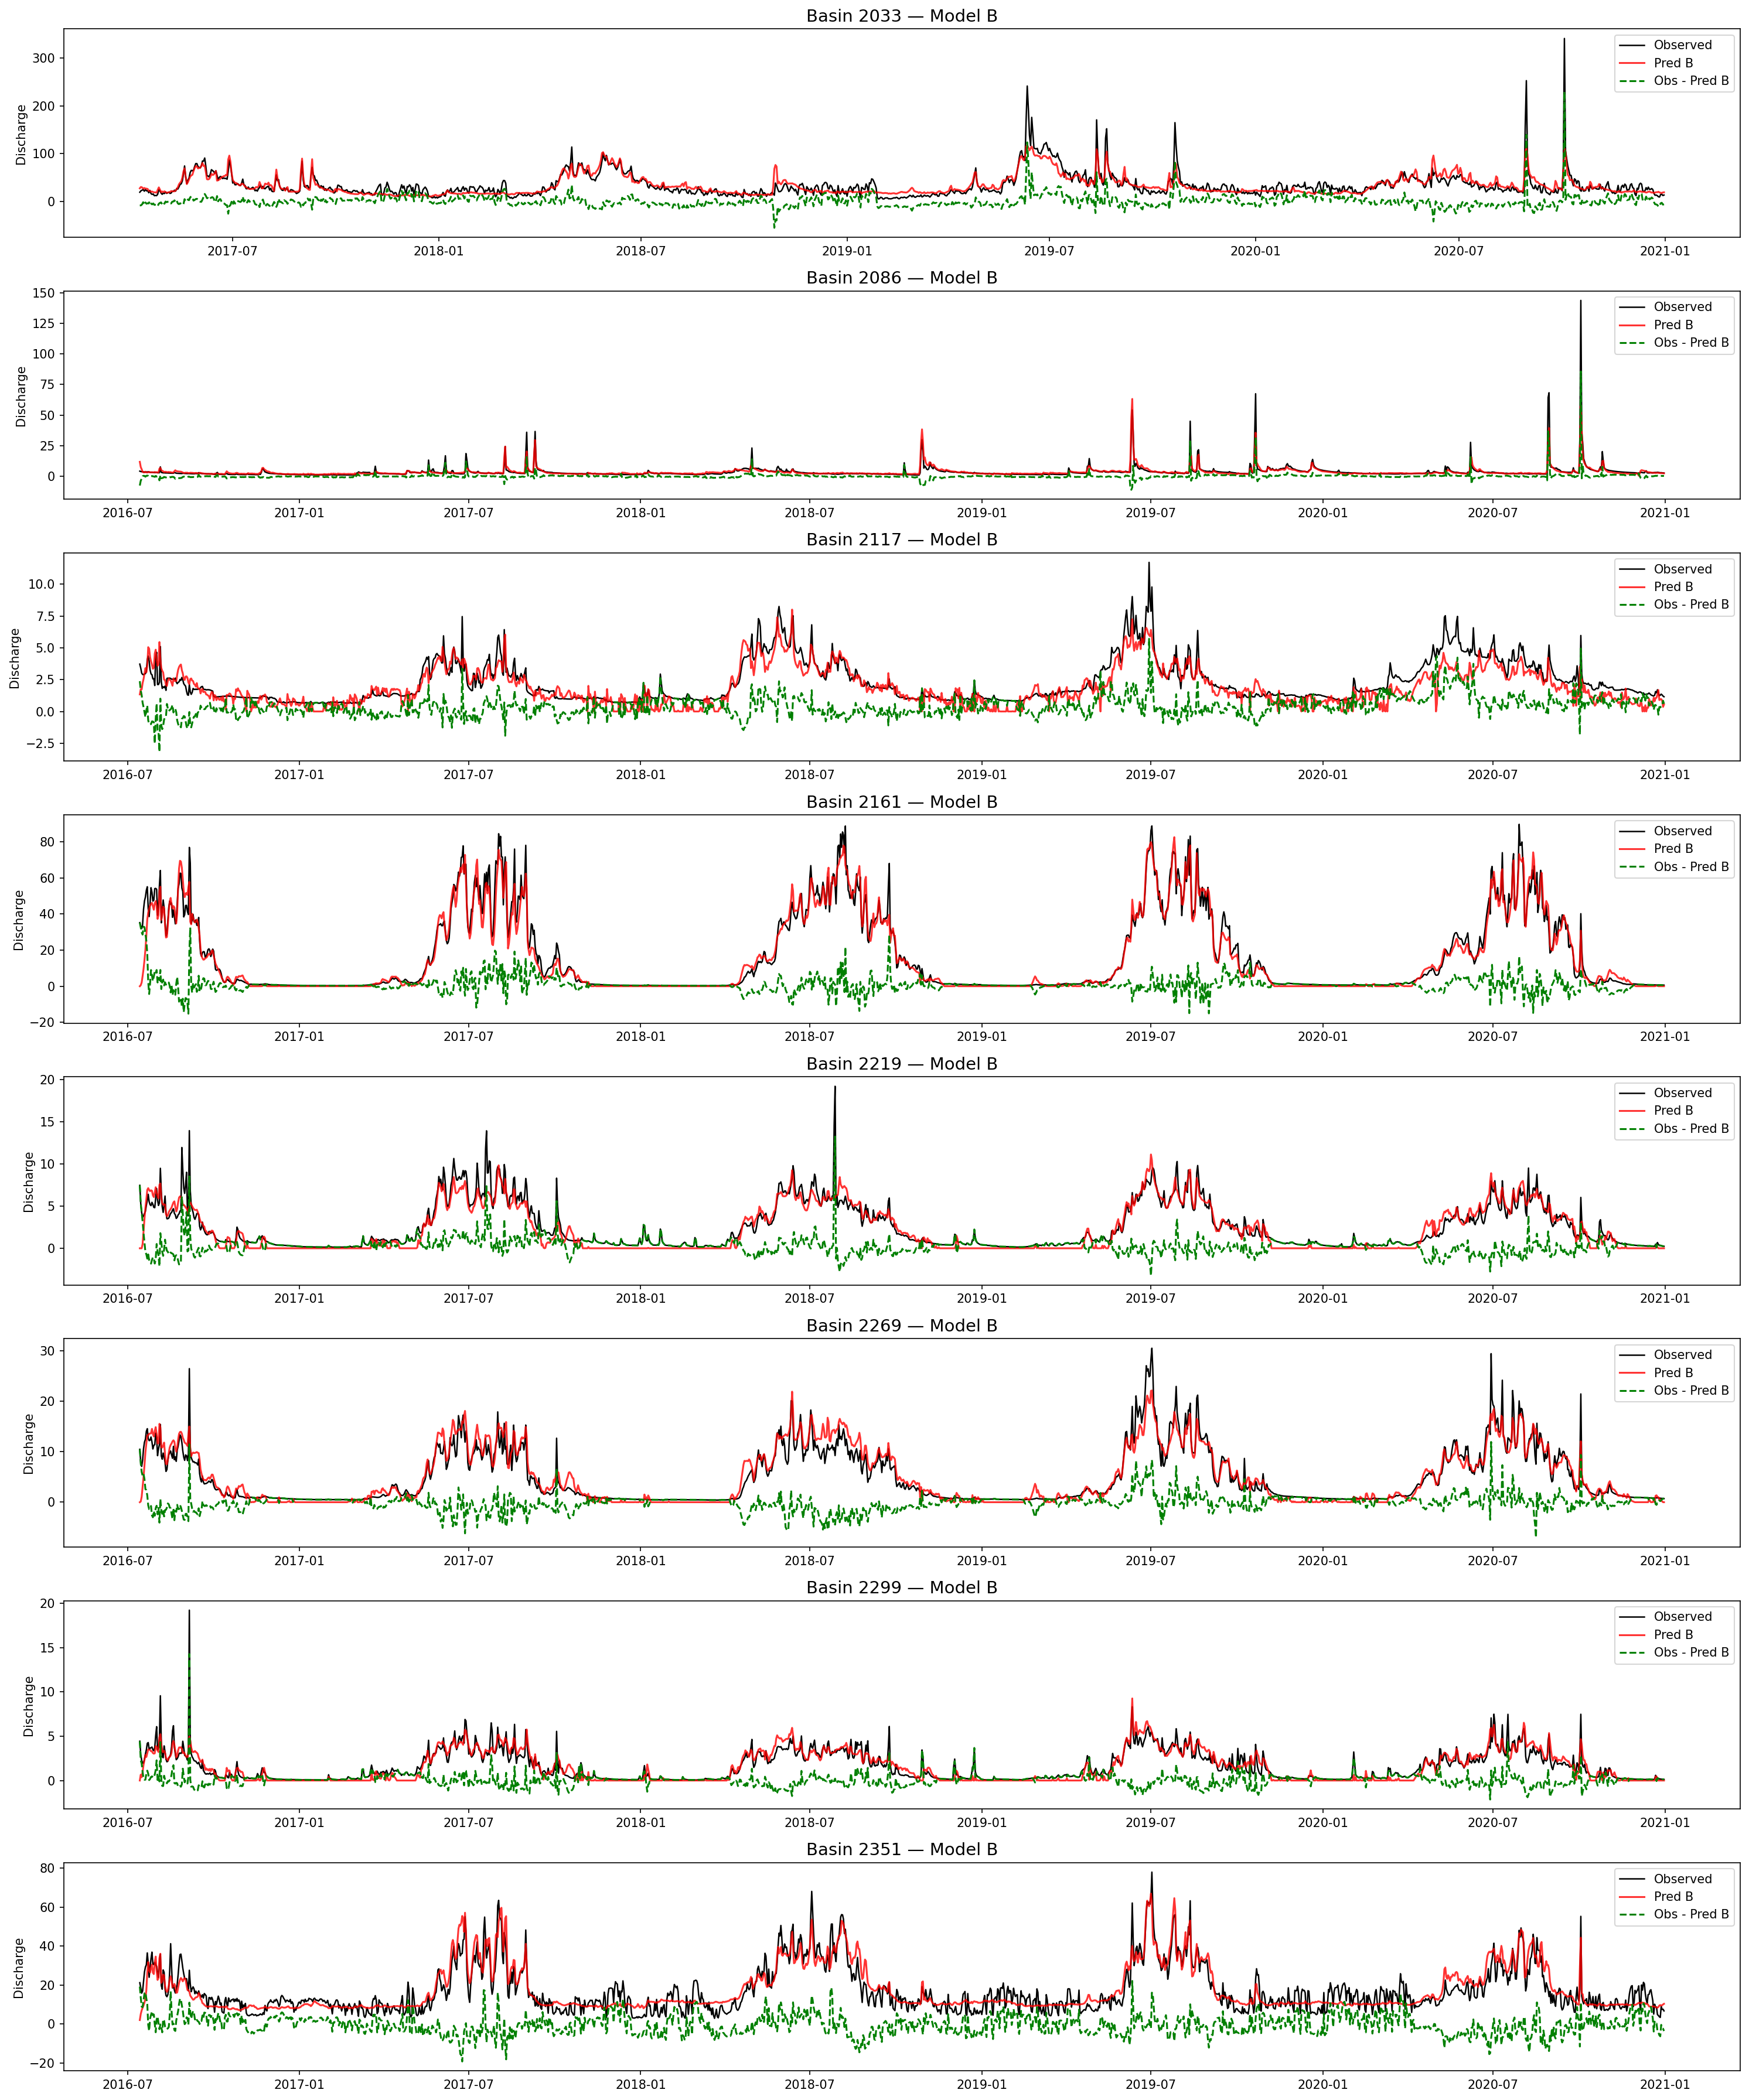

In [19]:
# Run evaluation and plotting for Model B on all test basins
pred_B, obs_B, diff_B = evaluate_and_plot_model_B(
    model_B,
    test_loader_B,
    df_test,
    sequence_length,
    basin_ids=df_test["gauge_id"].unique()
)

# Global Model A and B Feature Importance

In [20]:
# Permutation Feature Importance for LSTM Model (MSE or NSE)

def permutation_importance_lstm(model, test_loader, feature_names, metric="mse"):
    """Compute permutation feature importance for an LSTM model. metric: mse or nse"""

    model.eval()
    loss_fn = nn.MSELoss()

    # Baseline performance (no permutation)
    with torch.no_grad():
        preds, obs = [], []
        for Xb, yb in test_loader:
            preds.append(model(Xb).cpu())
            obs.append(yb.cpu())

    preds = torch.cat(preds)
    obs = torch.cat(obs)

    baseline_mse = loss_fn(preds, obs).item()

    # Baseline NSE if required
    if metric == "nse":
        global_mean = obs.mean()
        baseline_metric = (1 - torch.sum((preds - obs)**2) /
                           torch.sum((obs - global_mean)**2)).item()
    else:
        baseline_metric = baseline_mse

    print(f"Baseline {metric}: {baseline_metric:.5f}")

    # Compute permutation importance for each feature
    importances = []

    for f_idx, fname in enumerate(feature_names):
        worse_preds, worse_obs = [], []

        with torch.no_grad():
            for Xb, yb in test_loader:
                X_perm = Xb.clone()

                # Permute only this feature across samples
                torch.manual_seed(42 + f_idx)
                idx_perm = torch.randperm(Xb.shape[0])

                # apply permutation
                X_perm[:, :, f_idx] = X_perm[idx_perm, :, f_idx]

                pred_perm = model(X_perm)
                worse_preds.append(pred_perm.cpu())
                worse_obs.append(yb.cpu())

        worse_preds = torch.cat(worse_preds)
        worse_obs = torch.cat(worse_obs)

        perm_mse = loss_fn(worse_preds, worse_obs).item()

        # Compute metric degradation
        if metric == "nse":
            global_mean = worse_obs.mean()
            perm_metric = (1 - torch.sum((worse_preds - worse_obs)**2) /
                           torch.sum((worse_obs - global_mean)**2)).item()
            importance = baseline_metric - perm_metric
        else:
            importance = perm_mse - baseline_mse

        importances.append(importance)
        print(f"Feature: {fname:20s} → importance = {importance:.5f}")

    return importances

In [21]:
# Compute permutation feature importance for Model A (using MSE as metric)
feature_importance_A = permutation_importance_lstm(
    model_A,
    test_loader_A,
    feature_names=features_A,
    metric="mse"  # change to nse if you want to use Nash–Sutcliffe Efficiency
)

Baseline mse: 24.73807
Feature: waterlevel           → importance = 0.07697
Feature: precipitation        → importance = 50.86215
Feature: temperature_min      → importance = 13.32820
Feature: temperature_mean     → importance = 26.06021
Feature: temperature_max      → importance = 2.90221
Feature: rel_sun_dur          → importance = 1.84356
Feature: swe                  → importance = 11.72214
Feature: area                 → importance = 1.10936
Feature: elev_mean            → importance = 0.16100
Feature: elev_min             → importance = 0.14741
Feature: elev_max             → importance = 0.02771
Feature: slope_mean           → importance = 0.70623


In [22]:
# Compute permutation feature importance for Model A (using MSE as metric)
feature_importance_B = permutation_importance_lstm(
    model_B,
    test_loader_B,
    feature_names=features_B,
    metric="mse"
)

Baseline mse: 26.84566
Feature: waterlevel           → importance = 0.22411
Feature: precipitation        → importance = 45.48551
Feature: temperature_min      → importance = 13.19012
Feature: temperature_mean     → importance = 21.45783
Feature: temperature_max      → importance = 4.45801
Feature: rel_sun_dur          → importance = 3.38797
Feature: swe                  → importance = 12.18544
Feature: glac_area_ch_cont    → importance = 0.11080
Feature: glac_vol_ch_cont     → importance = 0.28251
Feature: glac_mass_ch_cont    → importance = 0.28685
Feature: area                 → importance = 1.02907
Feature: elev_mean            → importance = 0.44453
Feature: elev_min             → importance = 0.26493
Feature: elev_max             → importance = 0.48046
Feature: slope_mean           → importance = 0.21467


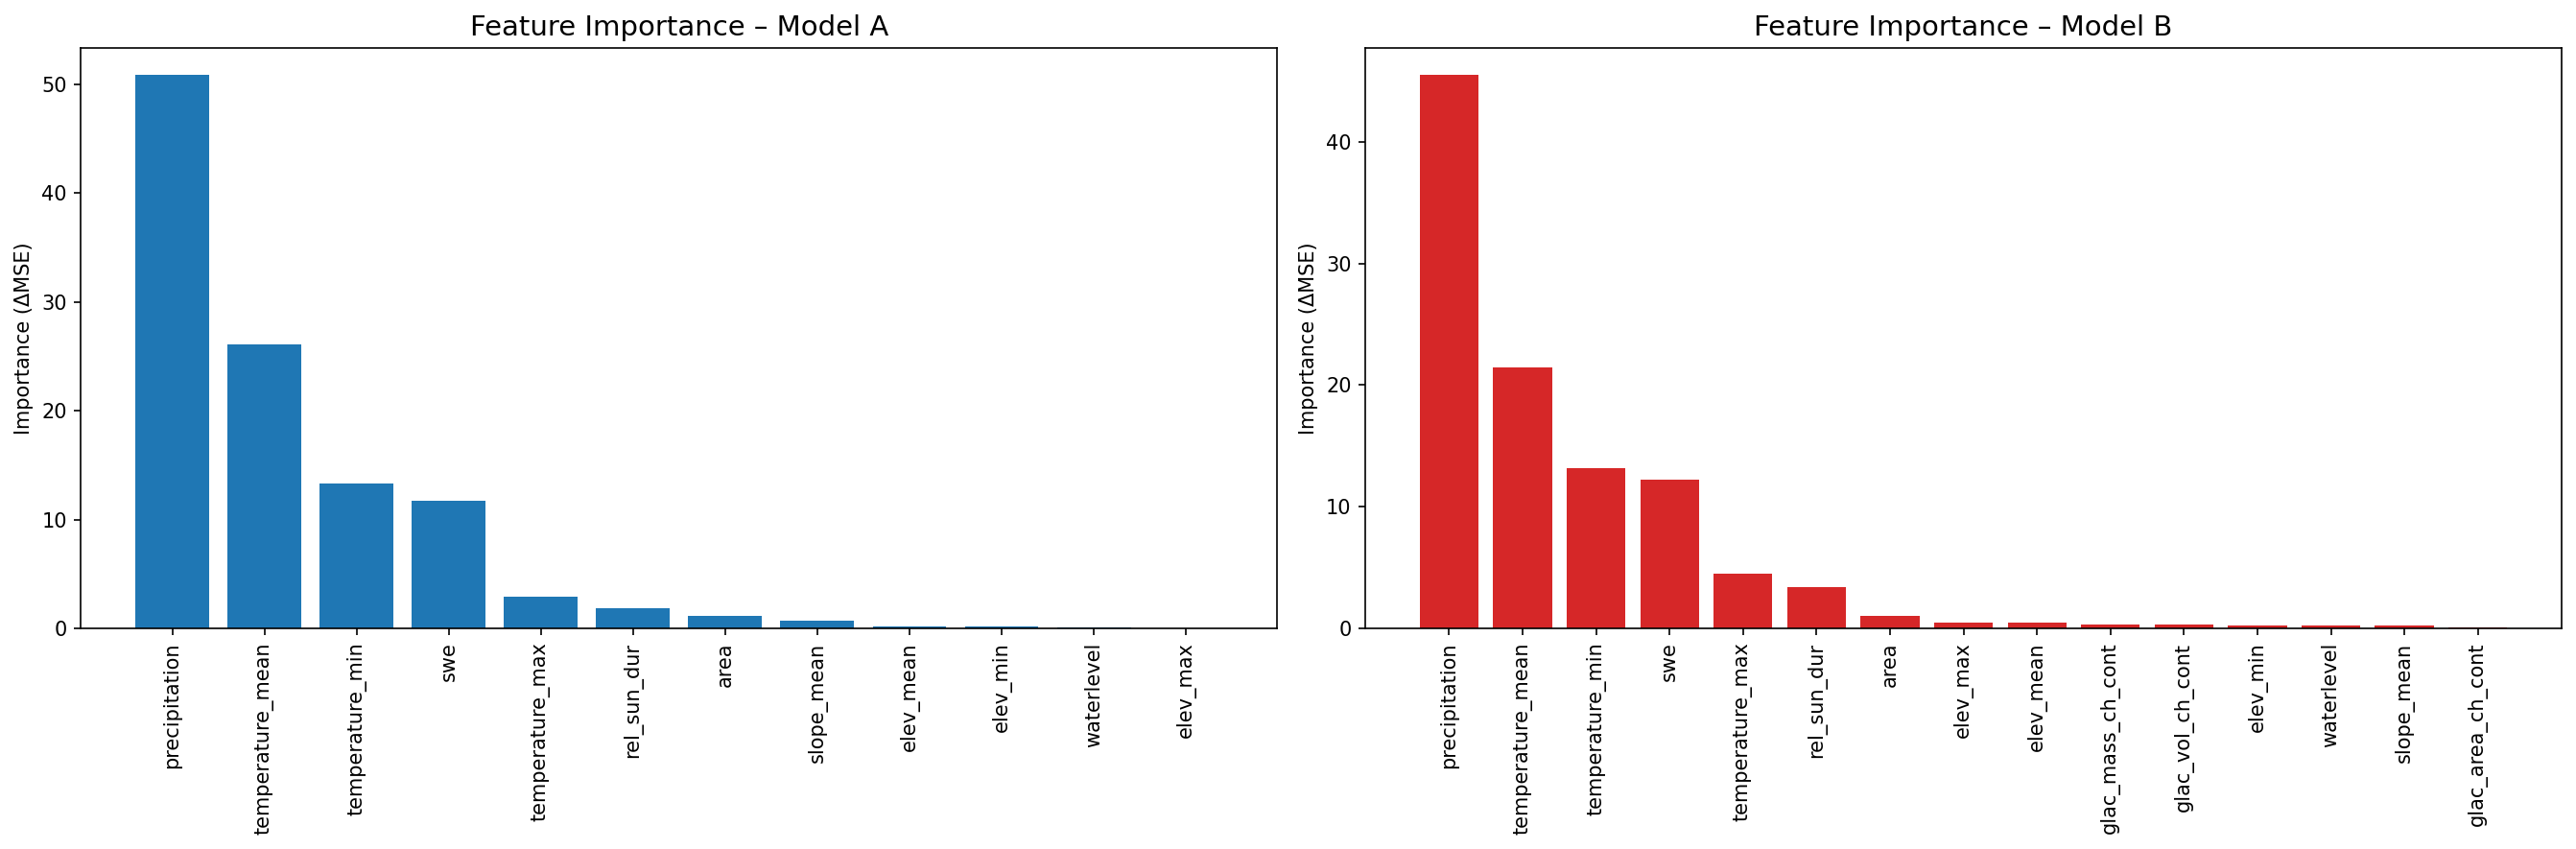

In [23]:
# Plot Feature Importance for Model A and B side-by-side
def plot_feature_importance_subplots(names_A, imp_A, names_B, imp_B, title_A, title_B):
    imp_A = np.array(imp_A)
    imp_B = np.array(imp_B)

    order_A = np.argsort(imp_A)[::-1]
    order_B = np.argsort(imp_B)[::-1]

    fig, axes = plt.subplots(1, 2, figsize=(18,6), dpi=150)

    # Left subplot: Model A
    axes[0].bar(np.array(names_A)[order_A], imp_A[order_A], color="tab:blue")
    axes[0].set_title(title_A, fontsize=14)
    axes[0].set_ylabel("Importance (ΔMSE)")
    axes[0].tick_params(axis='x', rotation=90)

    # Right subplot: Model B
    axes[1].bar(np.array(names_B)[order_B], imp_B[order_B], color="tab:red")
    axes[1].set_title(title_B, fontsize=14)
    axes[1].set_ylabel("Importance (ΔMSE)")
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()


# Call the combined subplot function
plot_feature_importance_subplots(
    features_A, feature_importance_A,
    features_B, feature_importance_B,
    "Feature Importance – Model A",
    "Feature Importance – Model B"
)

# Feature Importanc for specific catchements

In [24]:
# Build a DataLoader containing only sequences of a specific basin (silent version)
def make_basin_loader(test_loader, df_test, basin_id, seq_len, device="cpu"):

    basin_id = str(basin_id)                      # ensure gauge_id matches df format
    X_list, y_list = [], []

    df = df_test.reset_index(drop=True)           # keep alignment with sequences

    basin_mask = (df["gauge_id"].values == basin_id)
    basin_mask = basin_mask[seq_len - 1:]
    idxs = np.where(basin_mask)[0]

    if len(idxs) == 0:
        return None

    # Extract only the samples for this basin
    for i, (Xb, yb) in enumerate(test_loader):
        start = i * len(Xb)
        end = start + len(Xb)

        mask_batch = (idxs >= start) & (idxs < end)
        if not mask_batch.any():
            continue

        take = idxs[mask_batch] - start
        X_list.append(Xb[take].to(device))
        y_list.append(yb[take].to(device))

    if len(X_list) == 0:
        return None

    X = torch.cat(X_list)
    y = torch.cat(y_list)

    ds = TensorDataset(X, y)
    return DataLoader(ds, batch_size=64, shuffle=False)

In [25]:
# Compute permutation feature importance for one basin (silent, ΔMSE only)
def permutation_importance_single_basin(model, basin_loader, feature_names):

    model.eval()
    loss_fn = nn.MSELoss()

    # Compute baseline error for this basin
    with torch.no_grad():
        preds, obs = [], []
        for Xb, yb in basin_loader:
            preds.append(model(Xb).cpu())
            obs.append(yb.cpu())

    preds = torch.cat(preds)
    obs = torch.cat(obs)
    baseline_mse = loss_fn(preds, obs).item()

    importances = []

    # Compute ΔMSE for each feature by permuting it
    for f_idx, fname in enumerate(feature_names):

        worse_preds, worse_obs = [], []

        with torch.no_grad():
            for Xb, yb in basin_loader:
                X_perm = Xb.clone()
                idx_perm = torch.randperm(Xb.shape[0])
                X_perm[:, :, f_idx] = X_perm[idx_perm, :, f_idx]

                pred_perm = model(X_perm)
                worse_preds.append(pred_perm.cpu())
                worse_obs.append(yb.cpu())

        worse_preds = torch.cat(worse_preds)
        worse_obs = torch.cat(worse_obs)

        perm_mse = loss_fn(worse_preds, worse_obs).item()
        delta = perm_mse - baseline_mse
        importances.append(delta)

    return importances                                      # silent output

In [26]:
# Create a DataLoader for basin 2161 (Model B test set)
loader_2161 = make_basin_loader(test_loader_B, df_test, "2161", sequence_length, device)
# Compute permutation importance only if sequences exist for this basin
if loader_2161:
    fi_2161 = permutation_importance_single_basin(model_B, loader_2161, features_B)

# Basin 2299
loader_2299 = make_basin_loader(test_loader_B, df_test, "2299", sequence_length, device)
if loader_2299:
    fi_2299 = permutation_importance_single_basin(model_B, loader_2299, features_B)

# Basin 2269
loader_2269 = make_basin_loader(test_loader_B, df_test, "2269", sequence_length, device)
if loader_2269:
    fi_2269 = permutation_importance_single_basin(model_B, loader_2269, features_B)

# Basin 2117
loader_2117 = make_basin_loader(test_loader_B, df_test, "2117", sequence_length, device)
if loader_2117:
    fi_2117 = permutation_importance_single_basin(model_B, loader_2117, features_B)

# Basin 2351
loader_2351 = make_basin_loader(test_loader_B, df_test, "2351", sequence_length, device)
if loader_2351:
    fi_2351 = permutation_importance_single_basin(model_B, loader_2351, features_B)

# Basin 2219
loader_2219 = make_basin_loader(test_loader_B, df_test, "2219", sequence_length, device)
if loader_2219:
    fi_2219 = permutation_importance_single_basin(model_B, loader_2219, features_B)

# Basin 2033
loader_2033 = make_basin_loader(test_loader_B, df_test, "2033", sequence_length, device)
if loader_2033:
    fi_2033 = permutation_importance_single_basin(model_B, loader_2033, features_B)

# Basin 2086
loader_2086 = make_basin_loader(test_loader_B, df_test, "2086", sequence_length, device)
if loader_2086:
    fi_2086 = permutation_importance_single_basin(model_B, loader_2086, features_B)

/tmp/ipython-input-1137251062.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(features_B)[order], rotation=90)
/tmp/ipython-input-1137251062.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(features_B)[order], rotation=90)
/tmp/ipython-input-1137251062.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(features_B)[order], rotation=90)
/tmp/ipython-input-1137251062.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.array(features_B)[order], rotation=90)
/tmp/ipython-input-1137251062.py:31: UserWarning: set_ticklabels() should only be used w

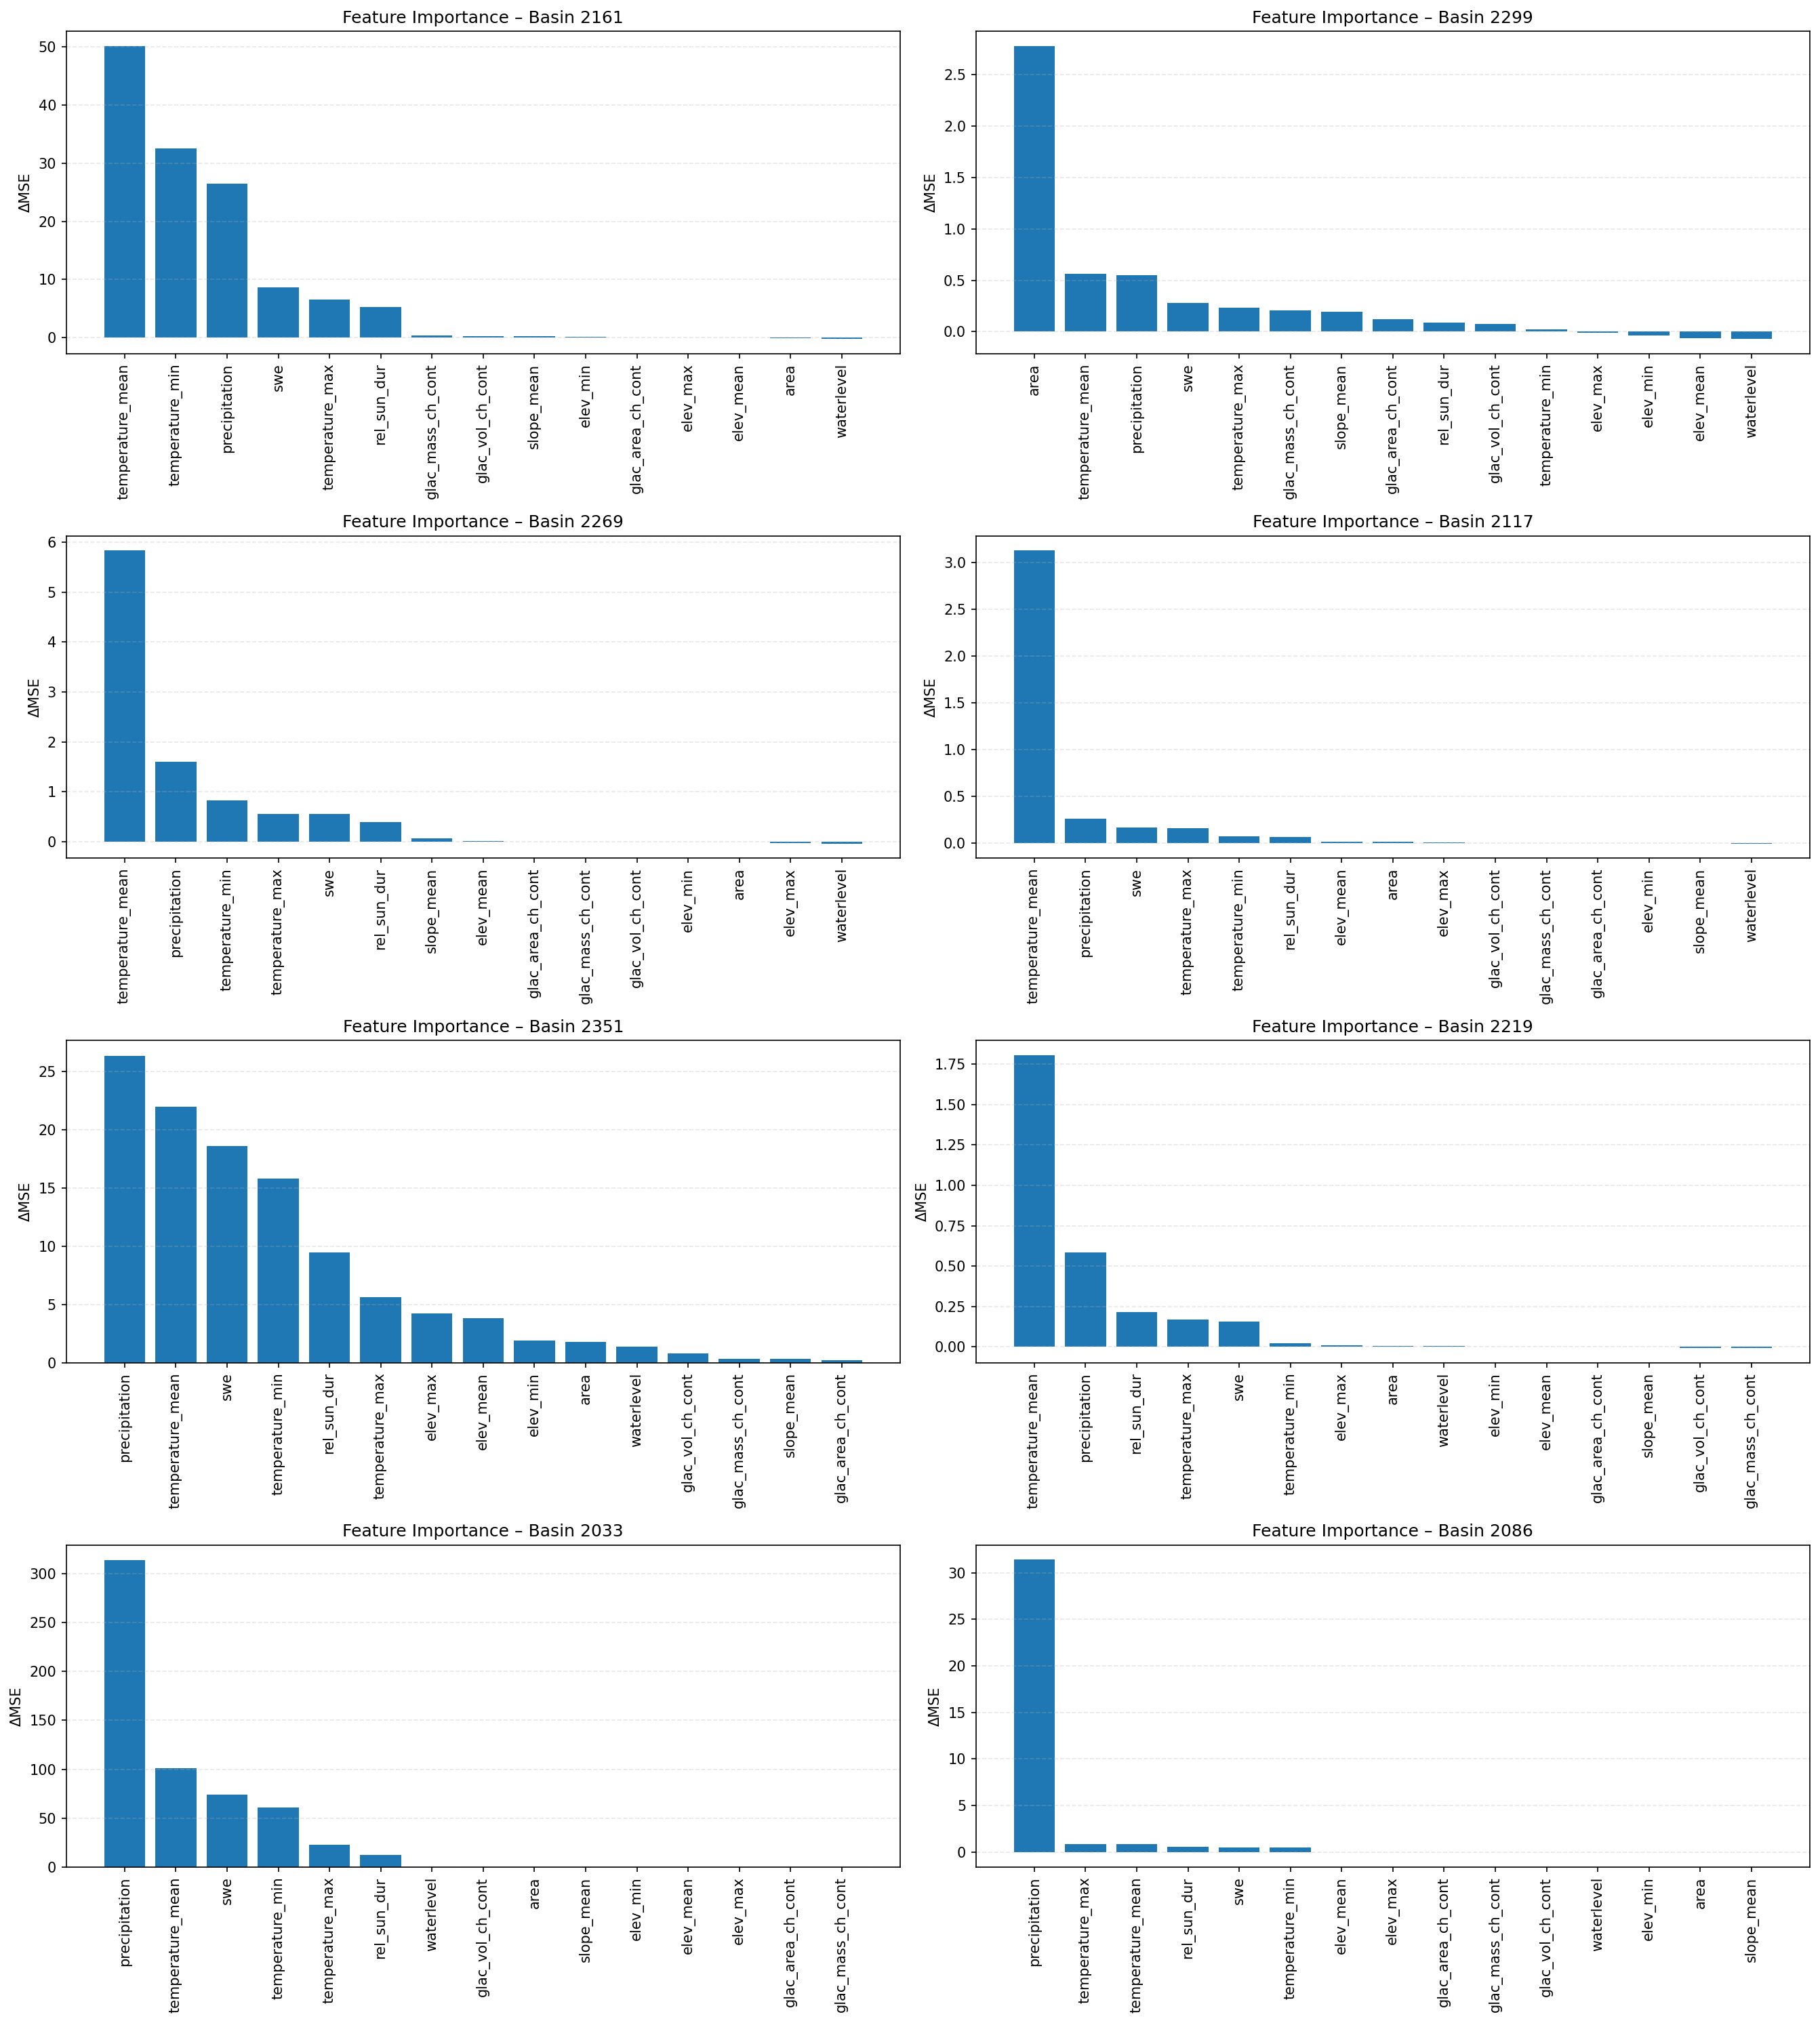

In [27]:
# Plot permutation importance for each basin

def plot_importance(names, importances, title):
    imp = np.array(importances)
    order = np.argsort(imp)[::-1]

    plt.figure(figsize=(12,6))
    plt.bar(np.array(names)[order], imp[order])
    plt.xticks(rotation=90)
    plt.ylabel("ΔMSE")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# Basin IDs and importance lists
basins = ["2161", "2299", "2269", "2117", "2351", "2219", "2033", "2086"]
fi_list = [fi_2161, fi_2299, fi_2269, fi_2117, fi_2351, fi_2219, fi_2033, fi_2086]

# Create subplot layout
fig, axes = plt.subplots(4, 2, figsize=(18, 20), dpi=150)
axes = axes.flatten()

# Plot feature importance for each basin
for ax, basin, fi in zip(axes, basins, fi_list):
    imp = np.array(fi)
    order = np.argsort(imp)[::-1]

    ax.bar(np.array(features_B)[order], imp[order])
    ax.set_title(f"Feature Importance – Basin {basin}")
    ax.set_xticklabels(np.array(features_B)[order], rotation=90)
    ax.set_ylabel("ΔMSE")
    ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Heat map for feature importance

In [28]:
def plot_fi_heatmap_norm_per_basin(features, fi_dict, title="Normalized FI per Basin"):
    """
    Normalize feature importance per basin by dividing each column by its maximum ΔMSE.
    Each basin (column) will be scaled to the range 0–1.
    """

    # Convert dictionary → DataFrame (rows = features, columns = basins)
    df_fi = pd.DataFrame(fi_dict, index=features)

    # Normalize each basin column by its own maximum ΔMSE
    df_norm = df_fi.copy()
    for basin in df_norm.columns:
        max_delta = df_norm[basin].max()
        df_norm[basin] = 0 if max_delta == 0 else df_norm[basin] / max_delta

    # Sort features by their mean normalized importance
    df_norm["mean"] = df_norm.mean(axis=1)
    df_norm = df_norm.sort_values("mean", ascending=False)
    df_norm = df_norm.drop(columns=["mean"])

    # Create Figure (IMPORTANT!)
    fig = plt.figure(figsize=(12, 8), dpi=150)

    # Plot heatmap ON THIS FIGURE
    sns.heatmap(df_norm, annot=True, fmt=".2f", cmap="magma",
                linewidths=0.5, vmin=0, vmax=1)

    plt.title(title, fontsize=16)
    plt.xlabel("Basin")
    plt.ylabel("Feature")
    plt.tight_layout()

    # ---- SAVE SVG BEFORE SHOW ----
    fig.savefig("feature_importance_heatmap.svg", format="svg", bbox_inches="tight")

    plt.show()

    return df_norm

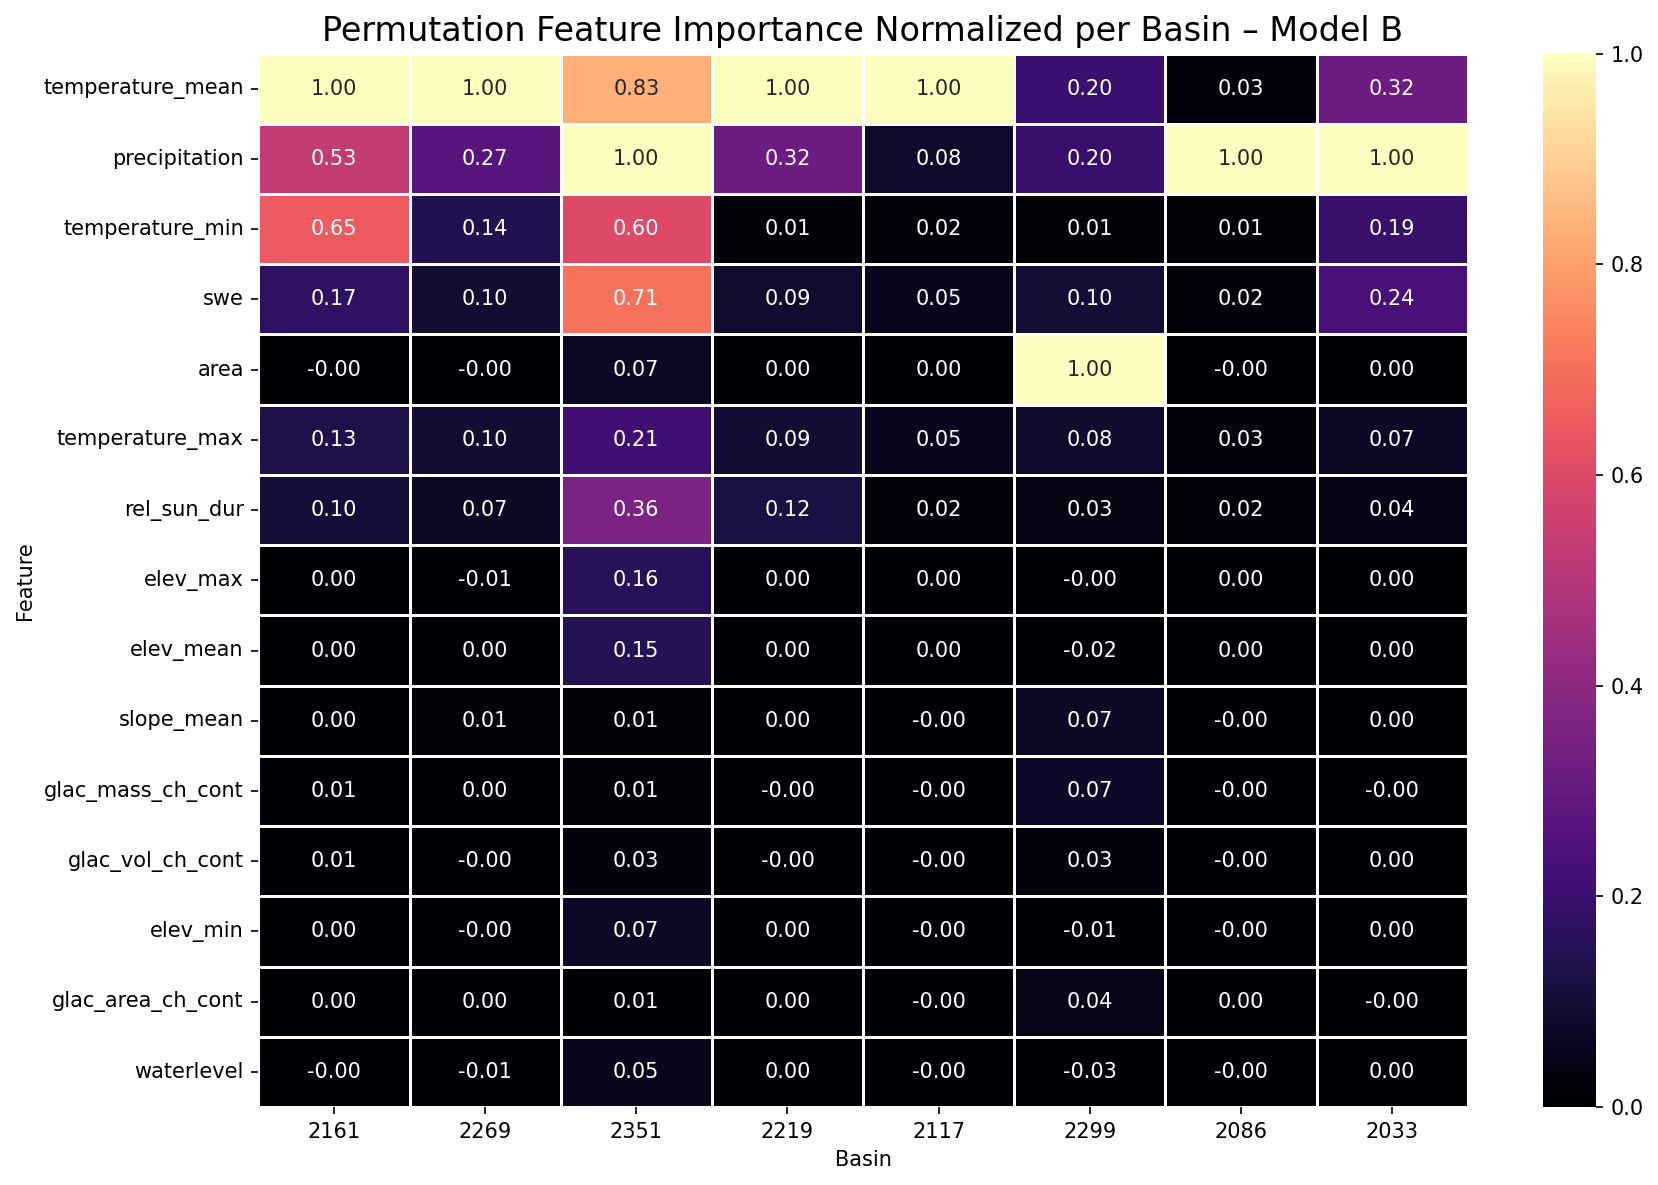

In [29]:
# Create a dictionary
fi_dict = {
    "2161": fi_2161,
    "2269": fi_2269,
    "2351": fi_2351,
    "2219": fi_2219,
    "2117": fi_2117,
    "2299": fi_2299,
    "2086": fi_2086,
    "2033": fi_2033
}

# Generate heatmap
df_norm = plot_fi_heatmap_norm_per_basin(
    features_B,
    fi_dict,
    title="Permutation Feature Importance Normalized per Basin – Model B"
)

# Uncertainity estimation (MC Dropout)

Running MC Dropout for MODEL A...


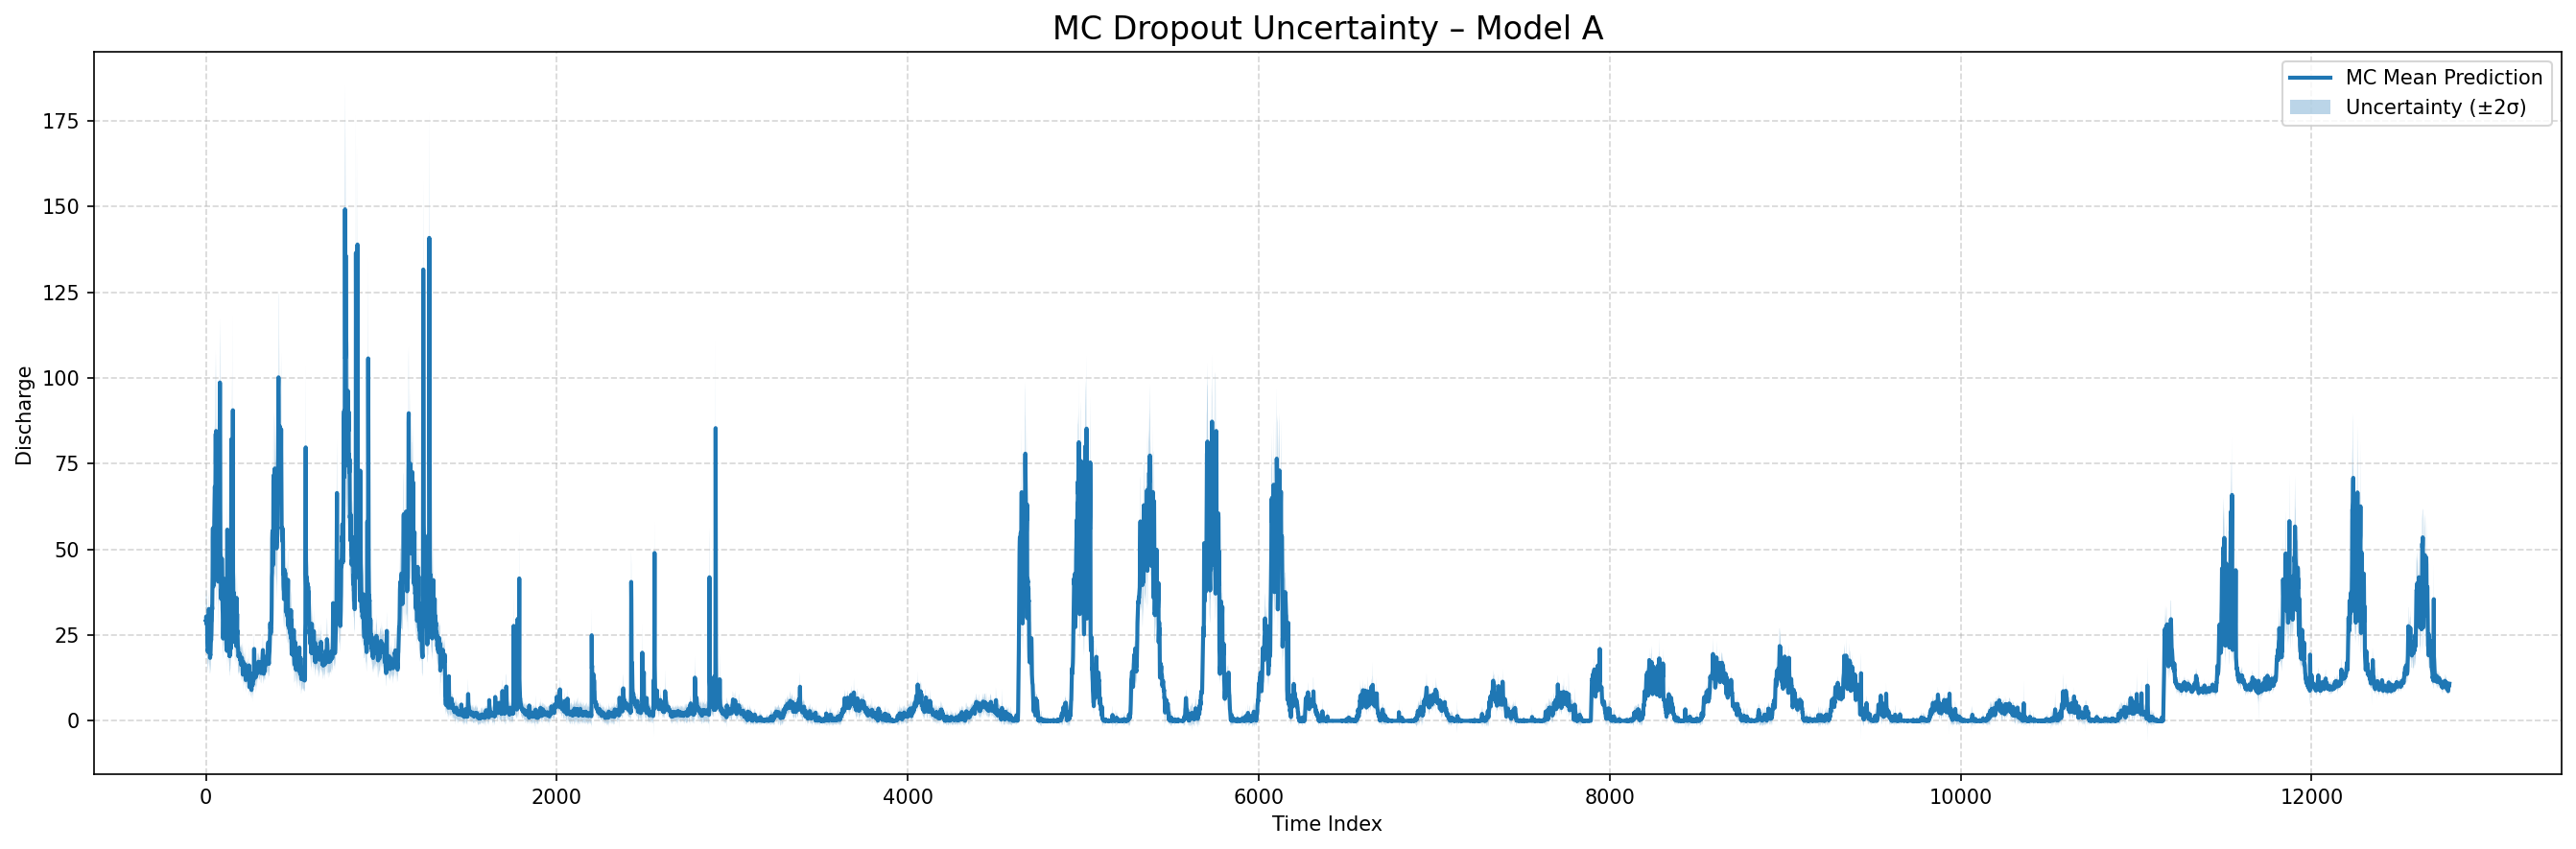

Running MC Dropout for MODEL B...


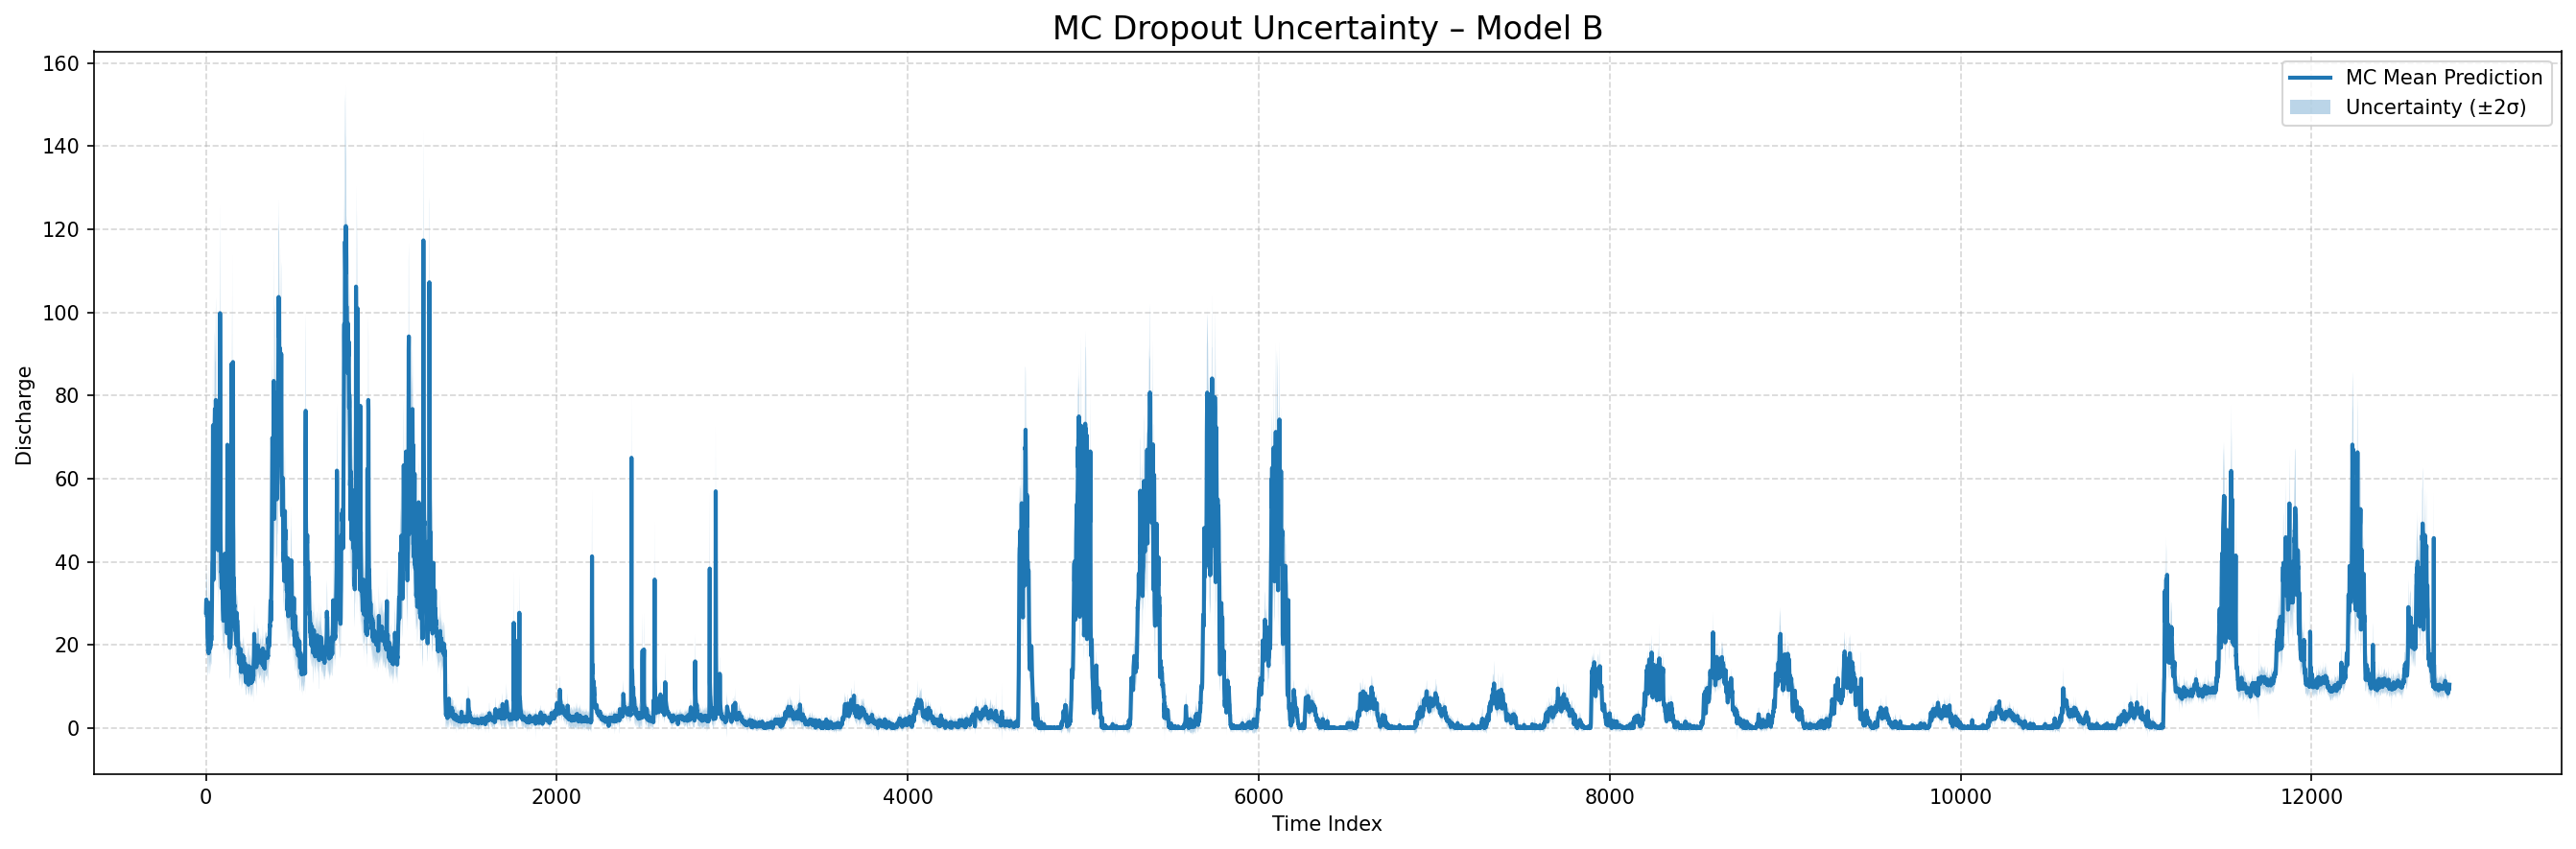

In [30]:
# Enable dropout layers during inference
def enable_dropout(model):
    """Force dropout layers to stay active during inference."""
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()

# Monte Carlo Dropout over a DataLoader (fast version)
def mc_dropout_on_loader_fast(model, loader, T=20, device="cpu"):
    """Run T stochastic forward passes and return mean and std predictions."""

    model.eval()
    enable_dropout(model)                # activate dropout for stochasticity

    all_preds = []

    with torch.no_grad():
        for t in range(T):
            batch_preds = []
            for Xb, _ in loader:
                y_hat = model(Xb.to(device))
                batch_preds.append(y_hat.cpu().numpy())
            batch_preds = np.concatenate(batch_preds)
            all_preds.append(batch_preds)

    all_preds = np.stack(all_preds)      # shape: (T, N_samples)
    mean_pred = all_preds.mean(axis=0)   # predictive mean
    std_pred  = all_preds.std(axis=0)    # predictive uncertainty

    return mean_pred, std_pred


# Plot predictions with ±2σ uncertainty band
def plot_predictions_with_uncertainty(mean_pred, std_pred, title):
    """Plot predictive mean and uncertainty interval."""

    x = np.arange(len(mean_pred))

    plt.figure(figsize=(18,6), dpi=150)
    plt.plot(x, mean_pred, label="MC Mean Prediction", linewidth=2)
    plt.fill_between(
        x,
        mean_pred - 2*std_pred,
        mean_pred + 2*std_pred,
        alpha=0.3,
        label="Uncertainty (±2σ)"
    )
    plt.title(title, fontsize=16)
    plt.xlabel("Time Index")
    plt.ylabel("Discharge")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# Run MC Dropout for Model A
print("Running MC Dropout for MODEL A...")
mean_A, std_A = mc_dropout_on_loader_fast(
    model_A,
    test_loader_A,
    T=20,
    device=device
)
plot_predictions_with_uncertainty(mean_A, std_A, "MC Dropout Uncertainty – Model A")


# Run MC Dropout for Model B
print("Running MC Dropout for MODEL B...")
mean_B, std_B = mc_dropout_on_loader_fast(
    model_B,
    test_loader_B,
    T=20,
    device=device
)
plot_predictions_with_uncertainty(mean_B, std_B, "MC Dropout Uncertainty – Model B")

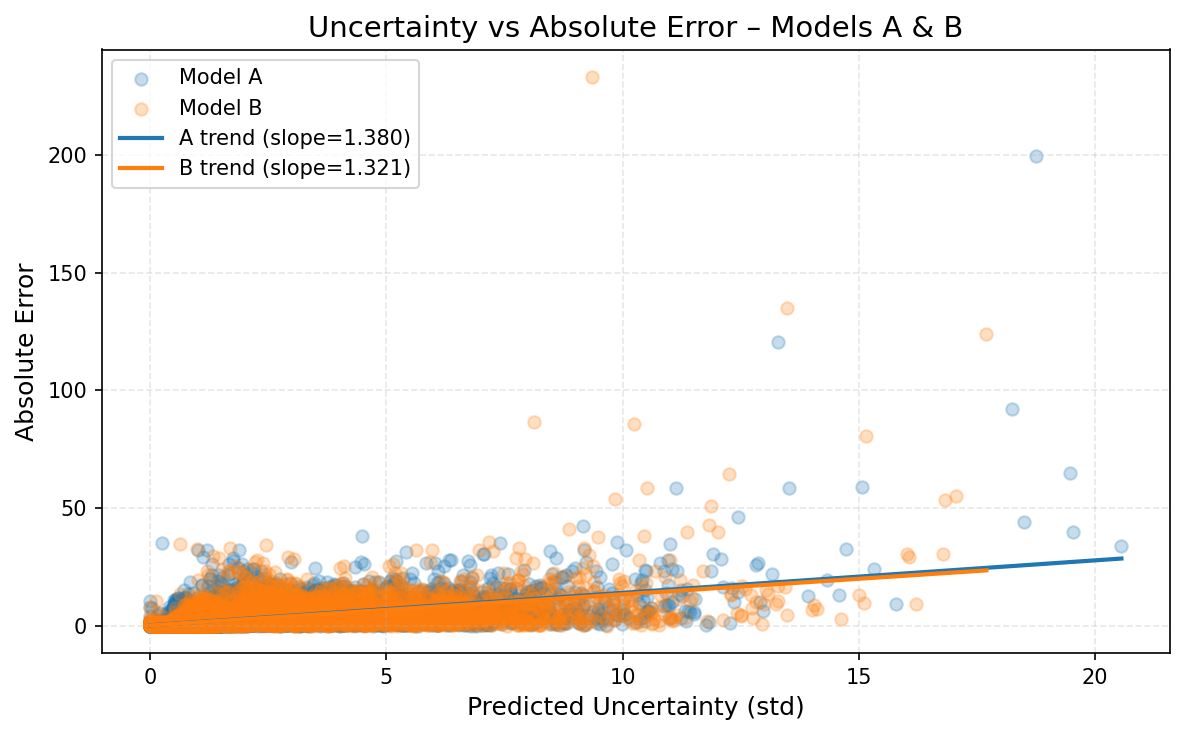

In [31]:
# Plot relationship between predictive uncertainty (std) and absolute error for Models A & B

def plot_uncertainty_vs_error_combined(std_A, mean_A, obs_A,
                                       std_B, mean_B, obs_B,
                                       title="Uncertainty vs Absolute Error – Models A & B"):

    # Compute absolute prediction errors
    err_A = np.abs(mean_A - obs_A)
    err_B = np.abs(mean_B - obs_B)

    plt.figure(figsize=(8,5), dpi=150)

    # Scatter points for both models
    plt.scatter(std_A, err_A, alpha=0.25, label="Model A", color="tab:blue")
    plt.scatter(std_B, err_B, alpha=0.25, label="Model B", color="tab:orange")

    # Linear trend line for Model A
    coeff_A = np.polyfit(std_A, err_A, 1)
    x_line_A = np.linspace(0, std_A.max(), 200)
    plt.plot(x_line_A, coeff_A[0] * x_line_A + coeff_A[1],
             color="tab:blue", linewidth=2,
             label=f"A trend (slope={coeff_A[0]:.3f})")

    # Linear trend line for Model B
    coeff_B = np.polyfit(std_B, err_B, 1)
    x_line_B = np.linspace(0, std_B.max(), 200)
    plt.plot(x_line_B, coeff_B[0] * x_line_B + coeff_B[1],
             color="tab:orange", linewidth=2,
             label=f"B trend (slope={coeff_B[0]:.3f})")

    # Labels and styling
    plt.xlabel("Predicted Uncertainty (std)", fontsize=12)
    plt.ylabel("Absolute Error", fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# Run uncertainty–error comparison for both models
plot_uncertainty_vs_error_combined(
    std_A, mean_A, y_test_A,
    std_B, mean_B, y_test_B
)

# Peak water analysis

In [32]:
# Sequential prediction over the full dataframe using sliding windows
def predict_sequential(model, df_scaled, df_original, features, seq_len, device):
    """
    Perform autoregressive-style predictions using sliding windows.
    Returns a dataframe with aligned predictions and observations.
    """

    model.eval()

    # Extract input features and target values
    X = df_scaled[features].values.astype(np.float32)
    y = df_original[target_col].values.astype(np.float32)

    preds, obs = [], []

    with torch.no_grad():
        # Slide window from seq_len-1 to the end of the dataset
        for i in range(seq_len - 1, len(X)):
            window = X[i - (seq_len - 1): i + 1]
            window_t = torch.tensor(window).unsqueeze(0).to(device)
            pred = model(window_t).cpu().numpy()[0]

            preds.append(pred)
            obs.append(y[i])

    # Build output dataframe aligned with predictions
    df_out = df_original.iloc[seq_len - 1:].copy()
    df_out["pred"] = np.array(preds)
    df_out["obs_sim"] = np.array(obs)

    return df_out

In [33]:
# Sequential predictions on the training set
df_train_full = predict_sequential(
    model_B, train_B_df, df_train, features_B, sequence_length, device
)

# Sequential predictions on the validation set
df_val_full = predict_sequential(
    model_B, val_B_df, df_val, features_B, sequence_length, device
)

# Sequential predictions on the test set
df_test_full = predict_sequential(
    model_B, test_B_df, df_test, features_B, sequence_length, device
)

# Concatenate all predictions into a single dataframe
df_all_full = pd.concat([df_train_full, df_val_full, df_test_full]).reset_index(drop=True)

In [34]:
# Plot observed, predicted, and trend line for a specific basin
def plot_test_basin_with_trend_on_axis(ax, df_sim, basin_id):

    # Select rows belonging to this basin
    sub = df_sim[df_sim["gauge_id"] == basin_id].copy()
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No data for basin {basin_id}", ha="center")
        ax.set_axis_off()
        return

    sub = sub.sort_values("date")

    # Prepare data for linear regression on predictions
    x = np.arange(len(sub))
    y = sub["pred"].values

    coeffs = np.polyfit(x, y, 1)
    trend = coeffs[0] * x + coeffs[1]
    slope, intercept = coeffs[0], coeffs[1]
    eq = f"y={slope:.3f}x + {intercept:.1f}"

    # Plot observed and simulated discharge
    ax.plot(sub["date"], sub["obs_sim"], color="black", linewidth=2, label="Observed")
    ax.plot(sub["date"], sub["pred"], linestyle="--", color="tab:blue", linewidth=2, label="Simulated")

    # Plot trend line
    ax.plot(sub["date"], trend, color="red", linewidth=2, alpha=0.8, label=f"Trend ({eq})")

    # Axis formatting
    ax.set_title(f"Basin {basin_id}", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

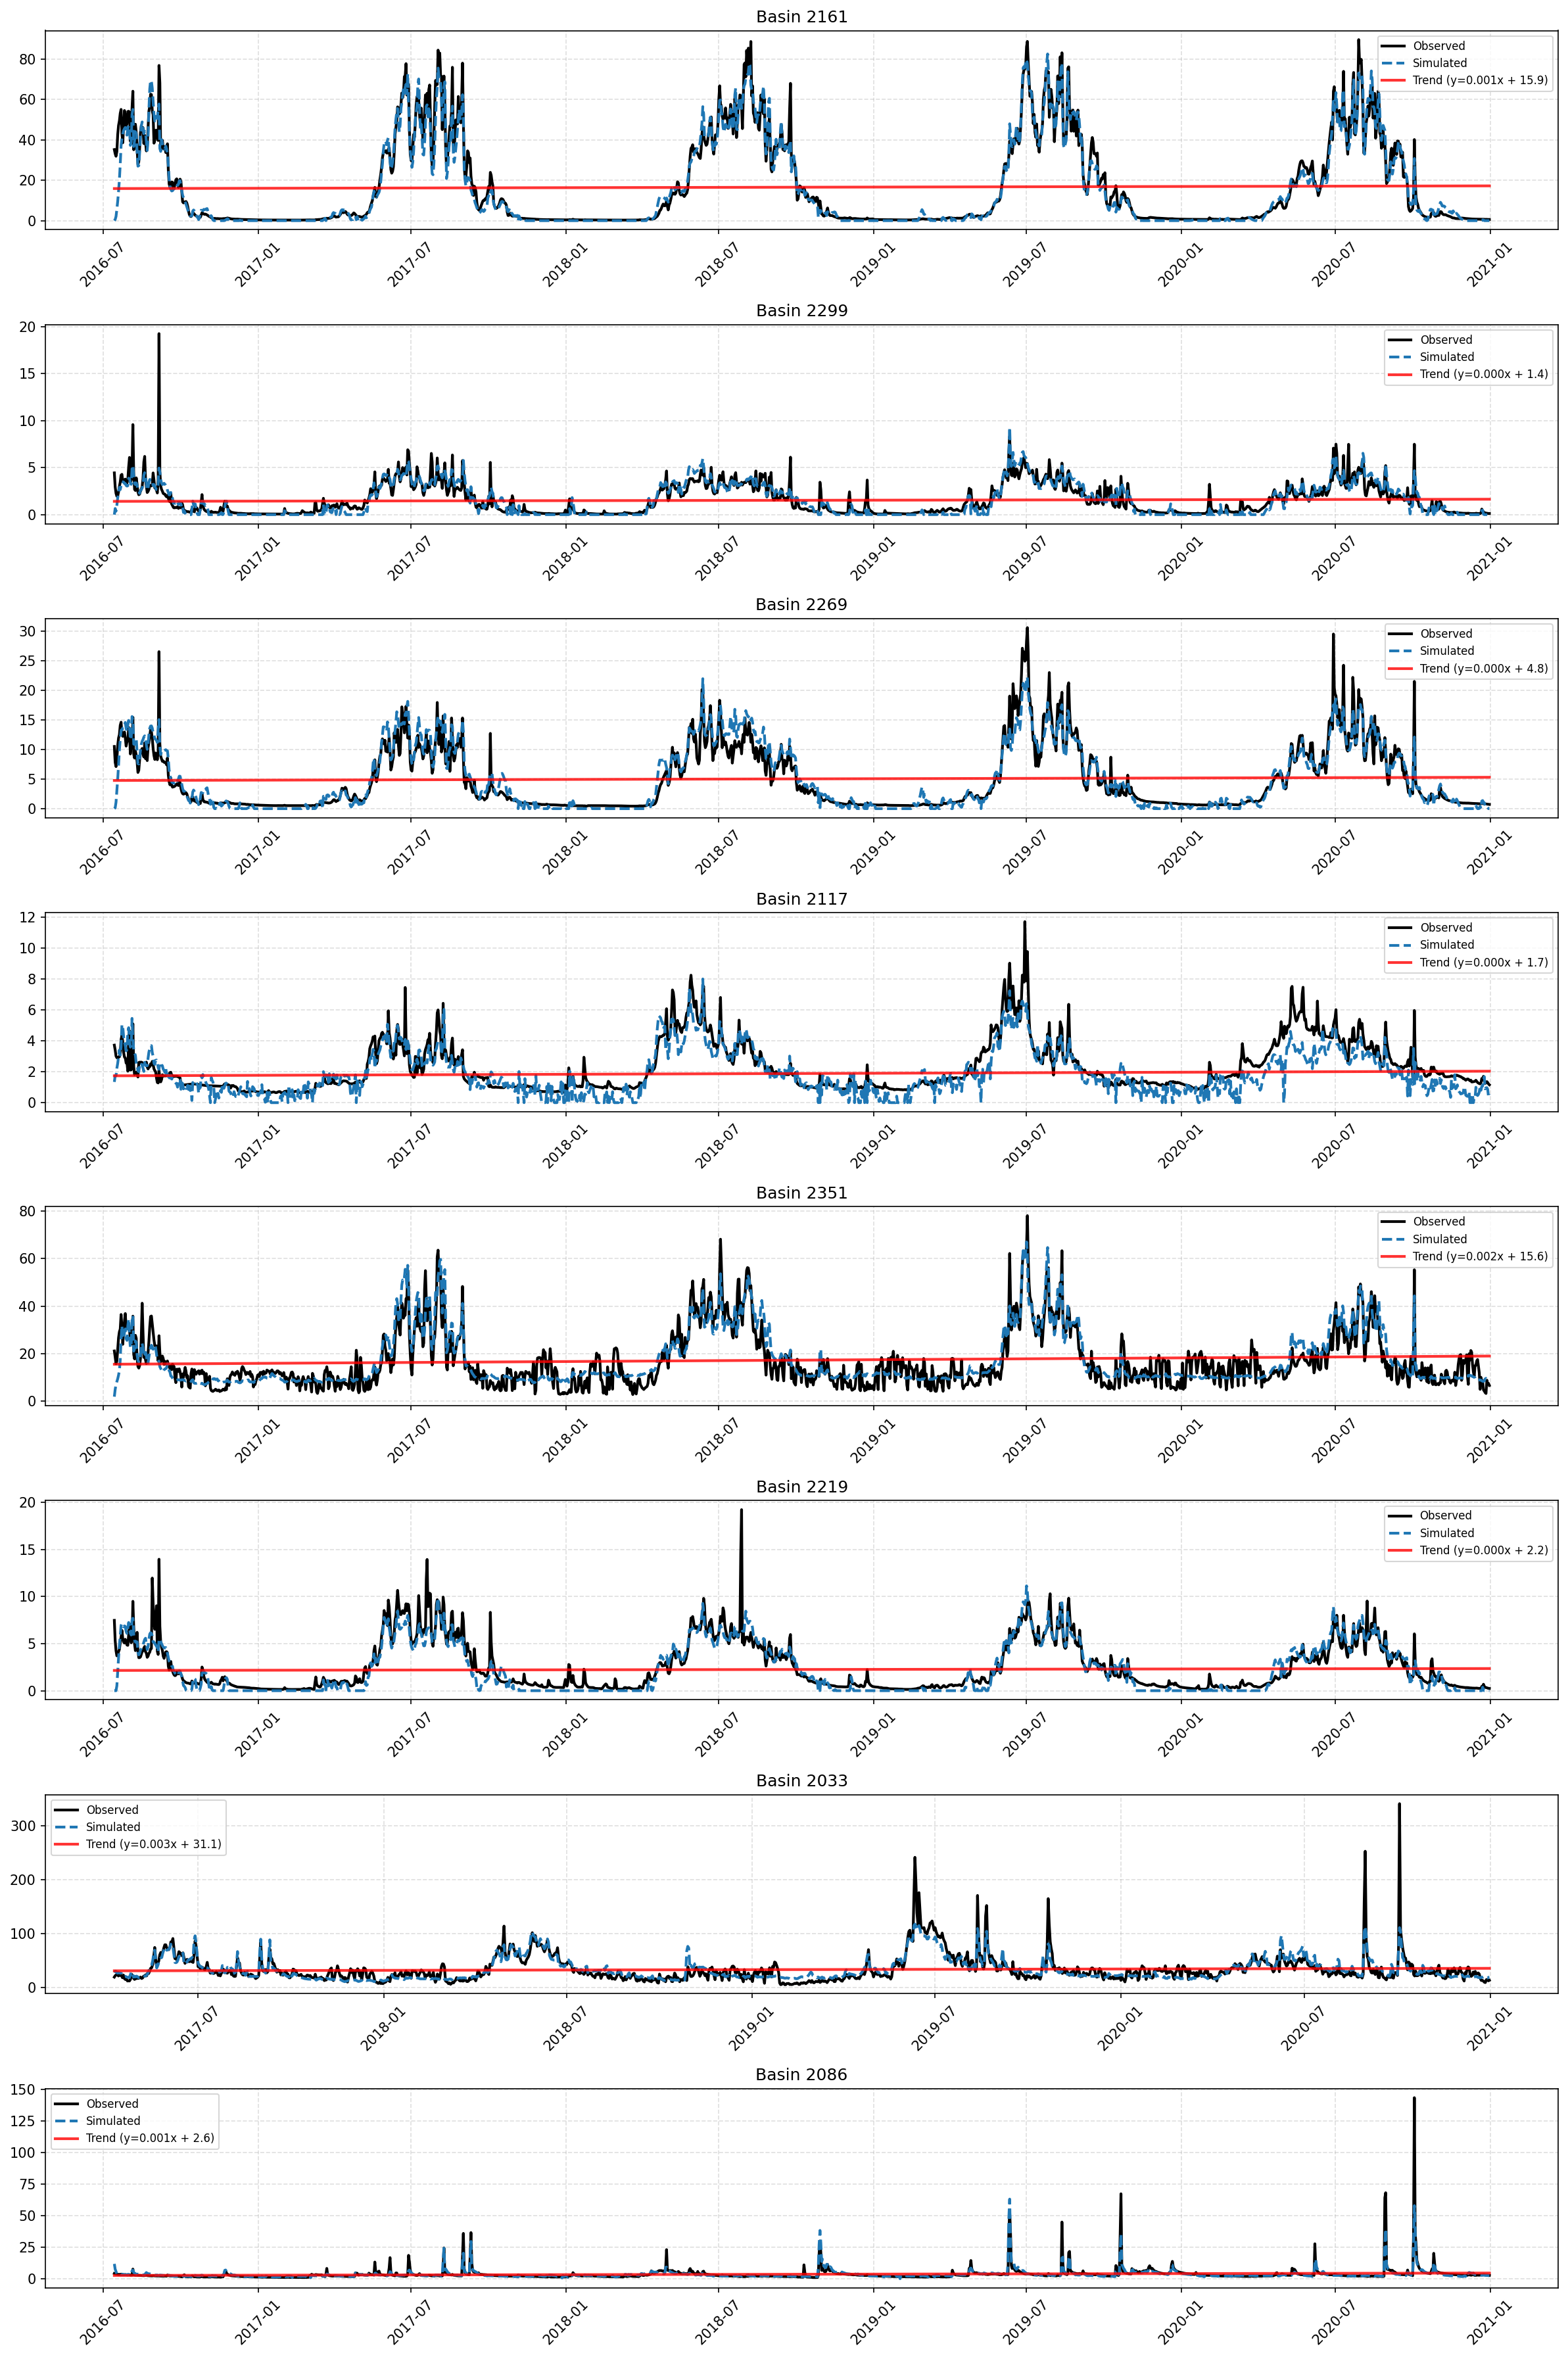

In [35]:
# Plot observed, simulated, and trend line for each basin
basins = ["2161", "2299", "2269", "2117", "2351", "2219", "2033", "2086"]

# Create one row per basin
fig, axes = plt.subplots(nrows=len(basins), ncols=1, figsize=(16, 3*len(basins)), dpi=150)

# Ensure axes is always iterable
if len(basins) == 1:
    axes = [axes]

# Plot each basin on its assigned axis
for ax, b in zip(axes, basins):
    plot_test_basin_with_trend_on_axis(ax, df_test_full, b)

plt.tight_layout()
plt.show()

In [36]:
# Plot annual mean observed vs simulated discharge with linear trend
def plot_annual_full_with_trend_on_axis(ax, df_all, basin_id):

    # Select basin rows
    sub = df_all[df_all["gauge_id"] == basin_id].copy()
    if len(sub) == 0:
        ax.text(0.5, 0.5, f"No data for basin {basin_id}", ha="center")
        ax.set_axis_off()
        return

    # Extract year for annual aggregation
    sub["year"] = sub["date"].dt.year

    # Compute annual averages (observed vs predicted)
    annual_obs  = sub.groupby("year")["obs_sim"].mean()
    annual_pred = sub.groupby("year")["pred"].mean()

    # Fit linear trend on simulated annual values
    x = np.arange(len(annual_pred))
    y = annual_pred.values
    coeffs = np.polyfit(x, y, 1)
    trend = coeffs[0] * x + coeffs[1]

    # R² of linear fit
    r2 = r2_score(y, trend)
    slope, intercept = coeffs[0], coeffs[1]
    eq = f"{slope:.3f}x + {intercept:.1f}  (R²={r2:.2f})"

    # Plot annual observed, simulated, and linear trend
    ax.plot(annual_obs.index, annual_obs.values, color="black", linewidth=2, label="Observed annual")
    ax.plot(annual_pred.index, annual_pred.values, linestyle="--", color="tab:blue", linewidth=2, label="Simulated annual")
    ax.plot(annual_pred.index, trend, color="red", linewidth=2, alpha=0.8, label=f"Trend ({eq})")

    # Formatting
    ax.set_title(f"Basin {basin_id}", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

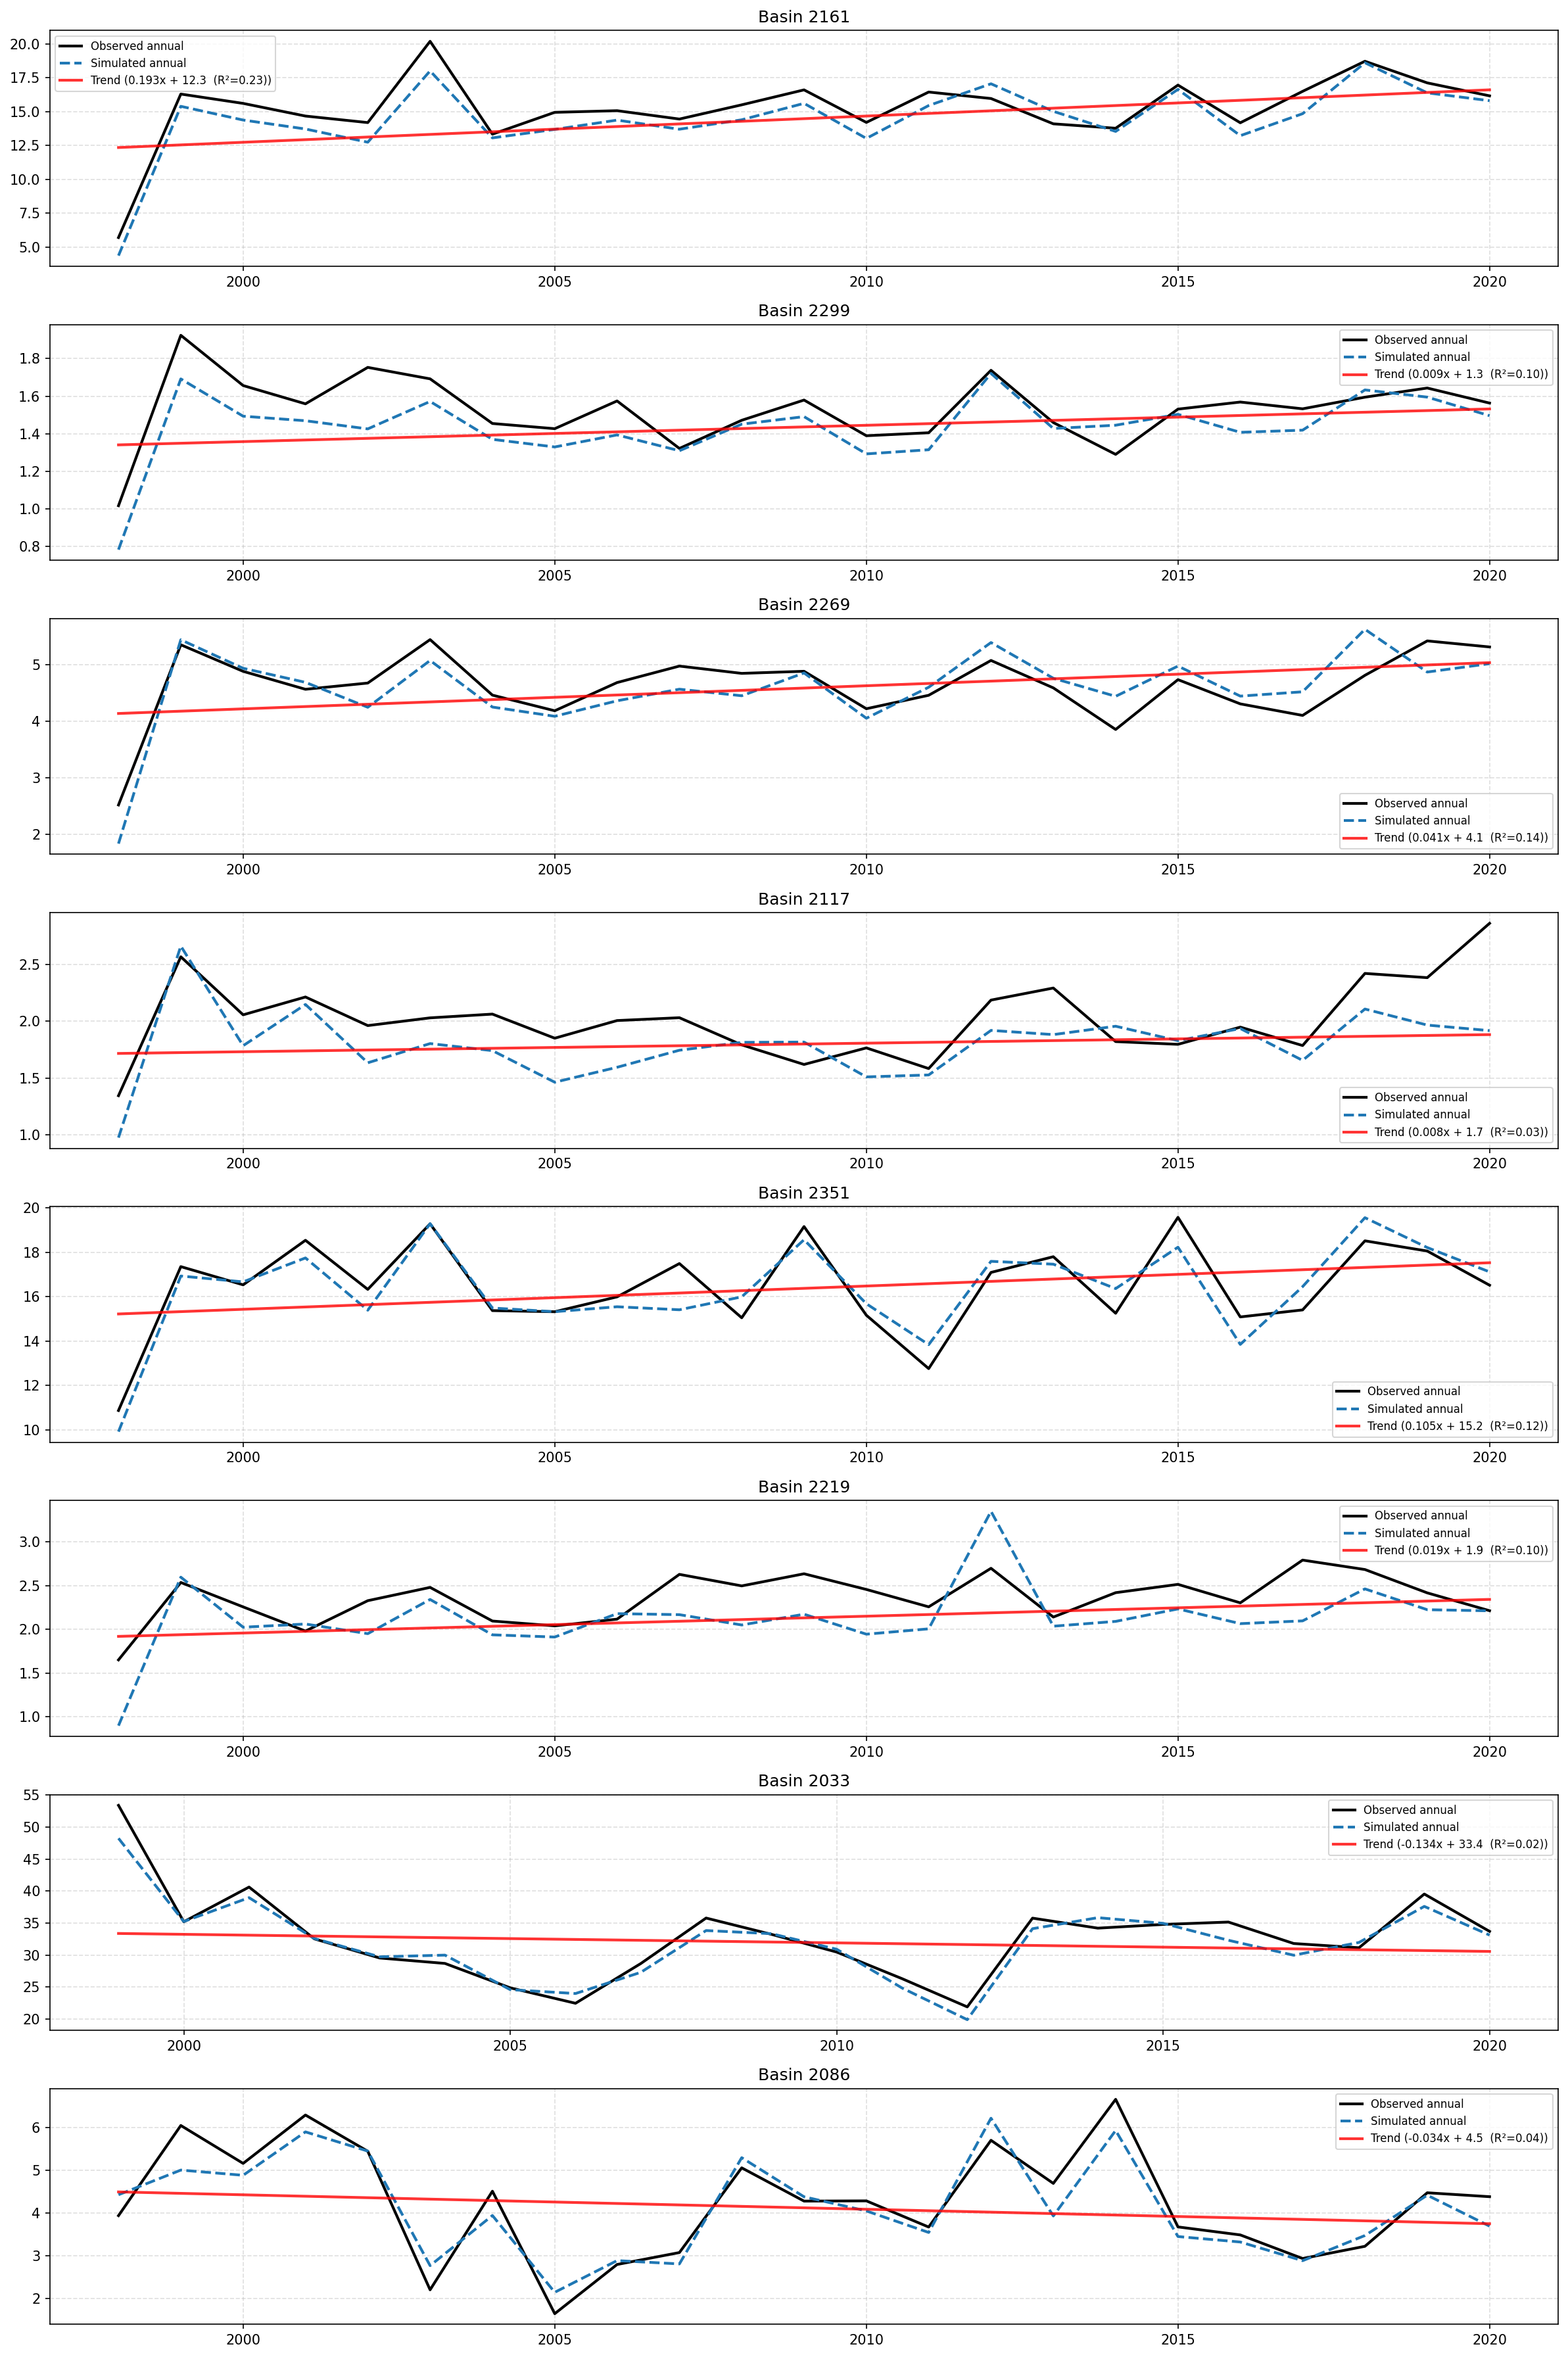

In [37]:
# Plot annual observed, simulated, and trend lines for each basin
fig, axes = plt.subplots(nrows=len(basins), ncols=1, figsize=(16, 3*len(basins)), dpi=150)

# Ensure axes is iterable even when there is only one basin
if len(basins) == 1:
    axes = [axes]

# Draw annual trend plots for each basin
for ax, b in zip(axes, basins):
    plot_annual_full_with_trend_on_axis(ax, df_all_full, b)

plt.tight_layout()

# Save plt in svg format
fig.savefig("annual_mean_trends.svg", format="svg", bbox_inches="tight")

plt.show()